# DAI Mission — Proposal Template
**Data & AI in Economics | TU Dortmund**

This notebook is your team's mission proposal. Fill in every section before submission. Once approved, you will extend this same notebook into your final deliverable.

> **Team size:** 2–3 students  
> **Deliverable:** This Jupyter Notebook (proposal → final submission in one file)


## 1. Team

| Role | Name |
|------|------|
| Lead | Oliver Ossadnik |
| Member | Danish Ahmad |


## 2. Mission Title & Research Question

**Title:** Clearing the Air: Evaluating Causal Policy Impacts, Meteorological Regimes, and Machine Learning Predictors of PM2.5 Pollution Across Five Chinese Macroeconomic Hubs

**Research question:** To what extent does the mandatory winter-heating policy in Northern Chinese cities (Beijing and Shenyang) causally increase hourly PM2.5 concentrations compared to Southern cities (Shanghai, Guangzhou, Chengdu) when adjusting for meteorological confounding factors, and how accurately can non-linear supervised learning models forecast these fluctuations using structural environmental features?

**Why it matters:** Air pollution acts as a severe negative economic externality of rapid industrialization, inflicting substantial public health costs, elevating mortality rates, and diminishing urban worker productivity. Disentangling the structural impact of regional public utility policies (such as centralized winter heating infrastructure) from purely natural meteorological variations is vital for designing sustainable urban regulations and optimizing green energy transitions without derailing regional economic growth.


## 3. Data

**Source(s):** * PM2.5 Data of Five Chinese Cities Dataset, hosted by the UCI Machine Learning Repository.
* URL: https://archive-beta.ics.uci.edu/dataset/394/pm2+5+data+of+five+chinese+cities
* Data Pedigree: Liang, X., Li, S., Zhang, S., Huang, H., and Chen, S. X. (2016). PM2.5 data reliability, consistency, and air quality assessment in five Chinese cities. Journal of Geophysical Research: Atmospheres, 121(17), 10,220-10,236.

**Unit of observation:** An hourly meteorological and air quality observation for a given city between January 1st, 2010, and December 31st, 2015.

**Key variables:**

| Variable | Type | Role (feature / target / instrument / ...) | Description |
|----------|------|---------------------------------------------|-------------|
| `PM` | Continuous | Target (Supervised) / Outcome (Causal) | PM2.5 concentration ($\mu g/m^3$) averaged across urban monitoring stations. |
| `heating_regime` | Binary (0 or 1) | Treatment Variable (Causal) | Engineered indicator: 1 if city is in the winter-heating region (Beijing/Shenyang) during active heating months (November 15 to March 15), 0 otherwise. |
| `TEMP` | Continuous | Feature / Confounder | Ambient temperature in Celsius. |
| `DEWP` | Continuous | Feature / Confounder | Dew Point temperature in Celsius. |
| `HUMI` | Continuous | Feature / Confounder | Humidity percentage (%). |
| `PRES` | Continuous | Feature / Confounder | Atmospheric pressure (hPa). |
| `Iws` | Continuous | Feature / Confounder | Cumulated wind speed (m/s). |
| `city` | Categorical | Feature / Context | The specific metropolitan center (Beijing, Shanghai, Guangzhou, Chengdu, Shenyang). |

**Potential data quality issues:** * **Missing Values (`NA`):** The target variable `PM` contains missing measurements during specific hours due to station equipment maintenance, requiring systematic forward-fill imputation.
* **Latent Missing Meteorological Fields:** Initial processing revealed hidden `NaN` entries in key weather parameters (`DEWP`, `Iws`) across specific years. Because machine learning models like K-Means clustering natively reject missing attributes, a strict drop-row filtration pipeline must be established across all core modeling features.


In [1]:

# =============================================================================
# GLOBAL SETUP — imports, reproducibility, and display configuration
# =============================================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression, RidgeCV
from scipy.stats import ks_2samp
import scipy.stats as stats

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CITIES = ["Beijing", "Shenyang", "Shanghai", "Chengdu", "Guangzhou"]
CITY_COLORS = {
    "Beijing": "#D55E00",
    "Shenyang": "#CC79A7",
    "Shanghai": "#0072B2",
    "Chengdu": "#009E73",
    "Guangzhou": "#E69F00",
}

print("✓ Global setup complete.")

✓ Global setup complete.


In [2]:
# =============================================================================
# STEP 1 — Data Ingestion & Cleaning
# =============================================================================

import os
from pathlib import Path
import pandas as pd
import numpy as np

# ── 1. File map ───────────────────────────────────────────────────────────────
# Necessary raw input files:
#   1) five UCI PM2.5 city CSVs
#   2) five Open-Meteo city weather CSVs
#   3) aggregated EDGAR emissions CSV for the causal/DAG support block

def find_uploaded_file(*patterns: str) -> str:
    """Find an input file either in the working directory or /mnt/data."""
    search_dirs = [Path("."), Path("/mnt/data")]
    for pattern in patterns:
        for folder in search_dirs:
            matches = sorted(folder.glob(pattern))
            if matches:
                return str(matches[0])
    raise FileNotFoundError(f"Could not find any file matching: {patterns}")

FILE_MAP = {
    "Beijing":   find_uploaded_file("BeijingPM20100101_20151231.csv",   "BeijingPM20100101_20151231*.csv"),
    "Shanghai":  find_uploaded_file("ShanghaiPM20100101_20151231.csv",  "ShanghaiPM20100101_20151231*.csv"),
    "Guangzhou": find_uploaded_file("GuangzhouPM20100101_20151231.csv", "GuangzhouPM20100101_20151231*.csv"),
    "Chengdu":   find_uploaded_file("ChengduPM20100101_20151231.csv",   "ChengduPM20100101_20151231*.csv"),
    "Shenyang":  find_uploaded_file("ShenyangPM20100101_20151231.csv",  "ShenyangPM20100101_20151231*.csv"),
}

OPENMETEO_FILES = {
    "Beijing":   find_uploaded_file("open-meteo-Beijing.csv",   "open-meteo-Beijing*.csv"),
    "Chengdu":   find_uploaded_file("open-meteo-Chengdu.csv",   "open-meteo-Chengdu*.csv"),
    "Guangzhou": find_uploaded_file("open-meteo-Guangzhou.csv", "open-meteo-Guangzhou*.csv"),
    "Shanghai":  find_uploaded_file("open-meteo-Shanghai.csv",  "open-meteo-Shanghai*.csv"),
    "Shenyang":  find_uploaded_file("open-meteo-Shenyang.csv",  "open-meteo-Shenyang*.csv"),
}

print("Input files selected for final notebook:")
for city, path in FILE_MAP.items():
    print(f"  PM        {city:10s}: {path}")
for city, path in OPENMETEO_FILES.items():
    print(f"  OpenMeteo {city:10s}: {path}")

# Structural columns shared across all five datasets.
# cbwd = combined wind direction, used only as fallback if Open-Meteo direction is unavailable.
# The original UCI precipitation field is never zero-imputed. It is replaced by
# consistently sourced Open-Meteo precipitation for all five cities.
CORE_COLS = ["city", "year", "month", "day", "hour", "season",
             "PM", "TEMP", "PRES", "HUMI", "DEWP", "Iws", "cbwd", "precipitation"]

# Features used in the unsupervised weather-regime analysis. Precipitation enters
# as log(1 + precipitation) to reduce the influence of rare extreme rainfall hours.
WEATHER_FEATURES = [
    "TEMP", "PRES", "HUMI", "DEWP", "Iws",
    "boundary_layer_height (m)", "cloud_cover (%)",
    "precipitation_log1p", "wind_sin", "wind_cos",
]
WIND_FEATURES = ["wind_sin", "wind_cos", "wind_dir_missing"]
WIND_DIRECTION = ["wind_sin", "wind_cos"]

# ── 2. Heating-regime definition ──────────────────────────────────────────────
# Treatment variable (causal block): binary indicator that equals 1 when
# the city is inside the government-mandated northern heating zone AND the
# actual heating-policy window is active.
#
# IMPORTANT CORRECTION:
# The broader Nov–Mar proxy was replaced by the more precise policy window:
#   November 15 → March 15
# This reduces measurement error around the beginning/end of the heating season.

HEATING_CITIES = {"Beijing", "Shenyang"}

def in_heating_policy_window(month: pd.Series, day: pd.Series) -> pd.Series:
    """Return True for dates inside the Nov 15–Mar 15 heating-policy window."""
    return (
        ((month == 11) & (day >= 15)) |
        (month.isin([12, 1, 2])) |
        ((month == 3) & (day <= 15))
    )

def engineer_heating_regime(df: pd.DataFrame) -> pd.DataFrame:
    """Add `heating_period` and binary `heating_regime` columns."""
    df = df.copy()
    df["heating_period"] = in_heating_policy_window(df["month"], df["day"]).astype(int)
    df["heating_regime"] = (
        df["city"].isin(HEATING_CITIES) & df["heating_period"].eq(1)
    ).astype(int)
    return df

# ── 3. Wind-direction encoding ────────────────────────────────────────────────
# Meteorological convention: North = 0°, East = 90°, South = 180°, West = 270°.
# The UCI files often contain cbwd values such as NE, NW, SE, SW and sometimes
# "cv" (calm/variable). Calm/variable has undefined direction, so we encode both
# sin/cos as 0 and set wind_dir_missing = 1.

WIND_ANGLE_MAP = {
    "N": 0, "NNE": 22.5, "NE": 45, "ENE": 67.5,
    "E": 90, "ESE": 112.5, "SE": 135, "SSE": 157.5,
    "S": 180, "SSW": 202.5, "SW": 225, "WSW": 247.5,
    "W": 270, "WNW": 292.5, "NW": 315, "NNW": 337.5,
}
CALM_OR_VARIABLE = {"CV", "CALM", "VARIABLE", "VAR", "NONE", ""}

def add_wind_direction_features(df: pd.DataFrame) -> pd.DataFrame:
    """Encode cbwd as circular wind_sin/wind_cos plus an undefined-direction flag."""
    df = df.copy()

    if "cbwd" not in df.columns:
        df["cbwd"] = np.nan

    cbwd = df["cbwd"].astype("string").str.strip().str.upper()
    angle = cbwd.map(WIND_ANGLE_MAP).astype(float)

    calm_or_variable = cbwd.isin(CALM_OR_VARIABLE)
    unmapped_or_missing = cbwd.isna() | (angle.isna() & ~calm_or_variable)
    undefined_direction = calm_or_variable | unmapped_or_missing

    theta = np.deg2rad(angle)
    df["wind_sin"] = np.sin(theta)
    df["wind_cos"] = np.cos(theta)

    # Undefined direction: no meaningful direction vector; set vector to zero
    # and let wind_dir_missing tell the model that direction was unavailable.
    df.loc[undefined_direction, ["wind_sin", "wind_cos"]] = 0.0
    df["wind_dir_missing"] = undefined_direction.astype(int)
    df["wind_angle"] = angle

    return df

# ── 4. Ingestion loop & Ersetzung für Beijing ──────────────────────────────────

def load_city(city: str, filename: str) -> pd.DataFrame:
    """Read one city CSV and return a cleaned slice with unified columns."""
    if not os.path.exists(filename):
        raise FileNotFoundError(
            f"Expected '{filename}' in the working directory."
        )

    df = pd.read_csv(filename, na_values=["NA", "NaN", " ", ""])
    df["city"] = city

    pm_cols = [c for c in df.columns if c.upper().startswith("PM_")]
    if not pm_cols:
        raise ValueError(f"No PM_* columns found in {filename}.")
    df["PM"] = df[pm_cols].mean(axis=1)

    for optional_col in ["cbwd", "precipitation"]:
        if optional_col not in df.columns:
            df[optional_col] = np.nan

    available = [c for c in CORE_COLS if c in df.columns]
    df = df[available].copy()
    return df

def replace_city_weather_with_exact_data(
    df_all_cities: pd.DataFrame, city_name: str, new_weather_path: str
) -> pd.DataFrame:
    """Replaces the imprecise UCI weather data for a specific city with the precise Open-Meteo CSV data."""
    print(
        f"\n── Replacing {city_name} weather data with high-resolution data ────────────────"
    )

    if not os.path.exists(new_weather_path):
        raise FileNotFoundError(
            f"Expected Open-Meteo file '{new_weather_path}' for {city_name}."
        )

    # 1. Separate data: Isolate only the specific city
    df_city = df_all_cities[df_all_cities["city"] == city_name].copy()
    df_other_cities = df_all_cities[
        df_all_cities["city"] != city_name
    ].copy()

    # If no data exists for this city, skip it
    if len(df_city) == 0:
        print(
            f"  ⚠️  No data found for {city_name} in the dataset. Skipping."
        )
        return df_all_cities

    # 2. Load new weather file (skip metadata rows)
    df_weather_new = pd.read_csv(new_weather_path, skiprows=3)

    # Parse timestamps correctly (ISO-8601 format with 'T')
    df_weather_new["time"] = pd.to_datetime(
        df_weather_new["time"], format="%Y-%m-%dT%H:%M"
    )

    # 3. Build a synchronization datetime axis for the city frame
    df_city["temp_datetime"] = pd.to_datetime(
        df_city[["year", "month", "day", "hour"]]
    )

    # 4. Drop old weather columns AND already existing new additional columns
    # This prevents suffix conflicts (_x, _y) in subsequent loop iterations!
    old_weather_columns = [
        "TEMP",
        "PRES",
        "HUMI",
        "DEWP",
        "cbwd",
        "Iws",
        "precipitation",
    ]

    # Which columns are brought in by the new weather file? (after mapping)
    new_features_mapped = [
        "wind_direction_10m (°)",
        "boundary_layer_height (m)",
        "rain (mm)",
        "snowfall (cm)",
        "TEMP",
        "PRES",
        "HUMI",
        "DEWP",
        "Iws",
        "precipitation",
        "wind_gusts_10m (km/h)",
        "cloud_cover (%)",
        "precipitation_log1p",
        "wind_angle",
    ]

    # Delete all old weather columns AND all columns that are about to enter via the merge
    columns_to_drop = set(
        old_weather_columns
        + new_features_mapped
        + ["wind_sin", "wind_cos", "wind_dir_missing"]
    )

    df_city = df_city.drop(
        columns=[col for col in columns_to_drop if col in df_city.columns]
    )

    # 5. Merge based on the exact timestamp
    df_city_new = pd.merge(
        df_city,
        df_weather_new,
        left_on="temp_datetime",
        right_on="time",
        how="inner",
    ).drop(
        columns=["temp_datetime", "time"]
    )  # 'time' is no longer required

    # 6. Map new column names to your project's naming scheme
    column_mapping = {
        "temperature_2m (°C)": "TEMP",
        "pressure_msl (hPa)": "PRES",
        "relative_humidity_2m (%)": "HUMI",
        "dew_point_2m (°C)": "DEWP",
        "wind_speed_10m (km/h)": "Iws",
        "precipitation (mm)": "precipitation",
    }
    df_city_new = df_city_new.rename(columns=column_mapping)

    # 7. Use the continuous Open-Meteo direction (0–360°).
    #    wind_angle is overwritten so there is no stale UCI direction column.
    df_city_new["wind_angle"] = df_city_new["wind_direction_10m (°)"].astype(float)
    theta = np.deg2rad(df_city_new["wind_angle"])
    df_city_new["wind_sin"] = np.sin(theta)
    df_city_new["wind_cos"] = np.cos(theta)
    df_city_new["wind_dir_missing"] = df_city_new["wind_angle"].isna().astype(int)

    # Precipitation is complete after the Open-Meteo merge. The log transform
    # limits the leverage of rare extreme precipitation in PCA and K-Means.
    df_city_new["precipitation_log1p"] = np.log1p(
        df_city_new["precipitation"].clip(lower=0)
    )

    # 8. Fill additional features in other cities with NaN
    additional_features = [
        c for c in df_city_new.columns if c not in df_other_cities.columns
    ]
    for col in additional_features:
        df_other_cities[col] = np.nan

    # 9. Re-unite both slices into a single dataframe
    df_other_cities = df_other_cities[
        df_city_new.columns
    ]  # Synchronize column order
    df_final_pipeline = pd.concat(
        [df_city_new, df_other_cities], ignore_index=True
    )
    print(f"  ✅ Successfully ingested. {city_name} rows: {len(df_city_new):,}")

    return df_final_pipeline


# === ACTUAL PIPELINE EXECUTION ===

print(
    "── Ingesting city datasets ──────────────────────────────────────────────"
)
city_frames = []
for city, filename in FILE_MAP.items():
    frame = load_city(city, filename)
    print(f"  {city:10s}  {len(frame):>7,} raw rows  |  PM cols averaged")
    city_frames.append(frame)

# 1. Concatenate all raw datasets
df_raw = pd.concat(city_frames, ignore_index=True)

# 2. Add heating regime flags
df_raw = engineer_heating_regime(df_raw)

# 3. Calculate wind features for remaining 4 cities (if necessary)
df_raw = add_wind_direction_features(df_raw)

# 4. NOW: Replace weather data for EACH city sequentially
# Replace weather records city by city
for city, filepath in OPENMETEO_FILES.items():
    df_raw = replace_city_weather_with_exact_data(df_raw, city, filepath)

print(
    f"\n  Combined & Replaced (raw):  {len(df_raw):>7,} rows × {df_raw.shape[1]} columns"
)

# ── 5. Temporal ordering ──────────────────────────────────────────────────────
# Sort the full panel chronologically within each city so that forward-fill
# operates strictly along the time axis.

df_raw = (df_raw
          .sort_values(["city", "year", "month", "day", "hour"])
          .reset_index(drop=True))

# =============================================================================
# Sensor anomaly handling: convert hidden -9999.0 error codes to NaN.
# =============================================================================
print("── Processing data quality check: Purging -9999 sensor faults ──────────")
for col in ["HUMI", "DEWP"]:
    if col in df_raw.columns:
        fault_count = (df_raw[col] == -9999.0).sum()
        print(f"  Found {fault_count:,} sensor error records (-9999.0) in column: {col}")
        df_raw[col] = df_raw[col].replace(-9999.0, np.nan)
print("  Purge successful. Anomalies converted to NaN placeholders.\n")

# Capture true raw missingness before PM forward-fill and row dropping.
missing_diagnostic_cols = ["PM"] + WEATHER_FEATURES + ["wind_direction_10m (°)", "precipitation"]
raw_missing_before_handling = (
    df_raw.groupby("city", observed=True)[missing_diagnostic_cols]
    .apply(lambda g: g.isna().sum())
)
precip_nulls_by_city = df_raw.groupby("city", observed=True)["precipitation"].apply(lambda g: g.isna().sum())

# ── 6. Missing-value handling ─────────────────────────────────────────────────
# Missing-value strategy:
#   (a) PM target: allow only one-hour forward fill within each city. This avoids
#       turning long monitor outages into artificial flat PM periods.
#   (b) Open-Meteo weather: require complete values for the clustering/model features.
#   (c) Precipitation: sourced consistently from Open-Meteo; never inferred from
#       missing UCI values and never filled with an invented zero.

print("── Missing-value strategy ───────────────────────────────────────────────")
print("  PM target       : forward-fill within city with limit=1 hour only")
print("  Weather features: require complete Open-Meteo values")
print("  Precipitation   : use observed Open-Meteo values; no artificial zero-imputation")

pm_nulls_before = df_raw["PM"].isna().sum()
df_raw["PM"] = df_raw.groupby("city", observed=True)["PM"].ffill(limit=1)
pm_nulls_after = df_raw["PM"].isna().sum()
print(f"  PM missing before limited ffill : {pm_nulls_before:,}")
print(f"  PM missing after limited ffill  : {pm_nulls_after:,}")

# Wind direction is added before dropna so all downstream steps can use it.
#THIS IS OUTDATED AND HAS ALREADY HAPPENED
#df_raw = add_wind_direction_features(df_raw)

#wind_undefined_by_city = df_raw.groupby("city", observed=True)["wind_dir_missing"].sum()
#print("\n── Wind-direction encoding ──────────────────────────────────────────────")
#print("  Created wind_sin, wind_cos, and wind_dir_missing from cbwd")
#print("  Undefined/calm/variable/missing wind-direction rows by city:")
#print(wind_undefined_by_city.to_string())

# Drop rows where model-critical fields remain missing. Precipitation is not in
# this subset because it is not used in the main model.
n_before_drop = len(df_raw)
CRITICAL_MODEL_COLS = ["PM"] + WEATHER_FEATURES + ["wind_dir_missing"]

df_clean = df_raw.dropna(subset=CRITICAL_MODEL_COLS).reset_index(drop=True)
n_dropped = n_before_drop - len(df_clean)
print(f"\n  Rows dropped (PM/weather/wind critical nulls): {n_dropped:,}")
print(f"  Rows retained (clean panel)                 : {len(df_clean):,}")

# ── 7. Treatment variable engineering ────────────────────────────────────────
df_clean = engineer_heating_regime(df_clean)

regime_counts = df_clean.groupby("city", observed=True)["heating_regime"].sum()
print(f"\n── heating_regime summary (treated hours per city) ─────────────────────")
print(regime_counts.to_string())

# ── 8. Data-type enforcement ──────────────────────────────────────────────────
# Categorical city saves memory and speeds groupby operations downstream.
df_clean["city"]    = df_clean["city"].astype("category")
df_clean["season"]  = df_clean["season"].astype("category")

# Ensure temporal integers are native int (not float from merge artefacts)
for col in ["year", "month", "day", "hour"]:
    df_clean[col] = df_clean[col].astype(int)

# ── 9. Sanity checks ──────────────────────────────────────────────────────────
print("\n── Sanity checks ────────────────────────────────────────────────────────")

# (i) Year coverage
print(f"  Year range  : {df_clean['year'].min()} – {df_clean['year'].max()}")

# (ii) No remaining nulls in model-critical columns
null_summary = df_clean[CRITICAL_MODEL_COLS + ["heating_regime"]].isnull().sum()
assert null_summary.sum() == 0, f"Unexpected nulls remaining:\n{null_summary[null_summary > 0]}"
print("  Null check  : PASSED — no missing values in critical model columns")

# (iii) Open-Meteo precipitation should be complete after the inner timestamp merge
precip_missing_clean = df_clean["precipitation"].isna().sum()
assert precip_missing_clean == 0, "Unexpected missing Open-Meteo precipitation values"
print("  Precip check: PASSED — observed Open-Meteo precipitation is complete")

# (iv) heating_regime is strictly binary
assert set(df_clean["heating_regime"].unique()).issubset({0, 1}), "heating_regime contains non-binary values"
print("  Binary check: PASSED — heating_regime ∈ {0, 1}")

# (v) All five cities present
assert set(df_clean["city"].astype(str).unique()) == set(FILE_MAP.keys()), "Missing cities in clean panel"
print(f"  Cities      : {sorted(df_clean['city'].astype(str).unique().tolist())}")

# (vi) PM values are non-negative (physical constraint)
assert (df_clean["PM"] >= 0).all(), "Negative PM2.5 values detected — check source data"
print(f"  PM range    : {df_clean['PM'].min():.1f} – {df_clean['PM'].max():.1f} µg/m³")

# ── 10. Final overview ────────────────────────────────────────────────────────
print("\n── Final dataset ────────────────────────────────────────────────────────")
print(f"  Shape  : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"  Memory : {df_clean.memory_usage(deep=True).sum() / 1e6:.1f} MB\n")

display(df_clean.head())
print("\n── Column dtypes & null counts ──────────────────────────────────────────")
df_clean.info()

print("\n── Descriptive statistics ───────────────────────────────────────────────")
display(df_clean.describe())

# =============================================================================
# STEP 1b — Pre-cleaning diagnostics (raw missingness, coverage, range checks)
# =============================================================================

print("── Pre-cleaning missingness (raw, before limited ffill/drop) ───────────")
display(raw_missing_before_handling)
print(f"\n  Total raw rows                 : {len(df_raw):,}")
print(f"  Total rows dropped (Step 1)    : {n_dropped:,} "
      f"({n_dropped / len(df_raw):.2%})")

# ── Precipitation coverage by city ───────────────────────────────────────────
print("\n── Precipitation coverage by city ──────────────────────────────────────")
print("  Open-Meteo precipitation replaces the incomplete UCI field; no invented zero-imputation is used.")
print(precip_nulls_by_city.to_string())

# ── Range / sanity checks on weather features (sensor-fault detection) ──────
print("\n── Weather feature range checks (post-clean) ───────────────────────────")
range_checks = df_clean[WEATHER_FEATURES + WIND_FEATURES].agg(["min", "max", "mean", "std"]).round(2)
display(range_checks)

# Flag physically implausible values
implausible = {
    "TEMP": ((df_clean["TEMP"] < -40) | (df_clean["TEMP"] > 50)).sum(),
    "PRES": ((df_clean["PRES"] < 850) | (df_clean["PRES"] > 1100)).sum(),
    "HUMI": ((df_clean["HUMI"] < 0) | (df_clean["HUMI"] > 100)).sum(),
    "Iws":  (df_clean["Iws"] < 0).sum(),
}
print("\n  Implausible-value counts (flagged, not removed):")
for k, v in implausible.items():
    print(f"    {k:6s}: {v}")

# ── Season consistency check ─────────────────────────────────────────────────
print("\n── Season label consistency ─────────────────────────────────────────────")
season_month_map = df_clean.groupby("season", observed=True)["month"].unique()
display(season_month_map.to_frame())

# ── 11. Export clean panel ───────────────────────────────────────────────────
# `df_clean` is the master panel carried forward into all subsequent blocks.
# Steps 2 (EDA), 3 (Causal), 4 (Supervised), and 5 (Unsupervised) all import it.
print("\n✓ Step 1 complete. Use `df_clean` in all downstream steps.")
print("  Main decisions: common Open-Meteo weather source, precipitation included via log1p,")
print("  PM ffill limited to 1 hour, Nov15–Mar15 heating period, continuous wind sin/cos, city-level PM averaging retained.")

Input files selected for final notebook:
  PM        Beijing   : BeijingPM20100101_20151231.csv
  PM        Shanghai  : ShanghaiPM20100101_20151231.csv
  PM        Guangzhou : GuangzhouPM20100101_20151231.csv
  PM        Chengdu   : ChengduPM20100101_20151231.csv
  PM        Shenyang  : ShenyangPM20100101_20151231.csv
  OpenMeteo Beijing   : open-meteo-Beijing.csv
  OpenMeteo Chengdu   : open-meteo-Chengdu.csv
  OpenMeteo Guangzhou : open-meteo-Guangzhou.csv
  OpenMeteo Shanghai  : open-meteo-Shanghai.csv
  OpenMeteo Shenyang  : open-meteo-Shenyang.csv
── Ingesting city datasets ──────────────────────────────────────────────
  Beijing      52,584 raw rows  |  PM cols averaged
  Shanghai     52,584 raw rows  |  PM cols averaged
  Guangzhou    52,584 raw rows  |  PM cols averaged
  Chengdu      52,584 raw rows  |  PM cols averaged
  Shenyang     52,584 raw rows  |  PM cols averaged

── Replacing Beijing weather data with high-resolution data ────────────────
  ✅ Successfully ingested. Be

,city,year,month,day,hour,season,PM,heating_period,heating_regime,TEMP,DEWP,precipitation,rain (mm),snowfall (cm),HUMI,Iws,wind_direction_10m (°),boundary_layer_height (m),PRES,wind_gusts_10m (km/h),cloud_cover (%),wind_angle,wind_sin,wind_cos,wind_dir_missing,precipitation_log1p
0,Beijing,2010,1,1,23,4.0,129.0,1,1,-4.1,-15.1,0.0,0.0,0.00,42.0,5.0,339.0,30.0,1019.3,11.2,87.0,339.0,-3.583679e-01,9.335804e-01,0,0.0
1,Beijing,2010,1,2,0,4.0,148.0,1,1,-4.4,-14.7,0.0,0.0,0.00,45.0,4.9,343.0,30.0,1019.5,10.8,90.0,343.0,-2.923717e-01,9.563048e-01,0,0.0
2,Beijing,2010,1,2,1,4.0,159.0,1,1,-4.5,-13.7,0.0,0.0,0.00,48.0,5.0,360.0,30.0,1020.7,9.7,86.0,360.0,-2.449294e-16,1.000000e+00,0,0.0
3,Beijing,2010,1,2,2,4.0,181.0,1,1,-4.6,-12.3,0.0,0.0,0.00,55.0,4.5,29.0,45.0,1021.0,7.2,97.0,29.0,4.848096e-01,8.746197e-01,0,0.0
4,Beijing,2010,1,2,3,4.0,138.0,1,1,-4.9,-10.2,0.0,0.0,0.07,66.0,4.3,90.0,95.0,1022.0,7.9,98.0,90.0,1.000000e+00,6.123234e-17,0,0.0



── Column dtypes & null counts ──────────────────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 175993 entries, 0 to 175992
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   city                       175993 non-null  category
 1   year                       175993 non-null  int64   
 2   month                      175993 non-null  int64   
 3   day                        175993 non-null  int64   
 4   hour                       175993 non-null  int64   
 5   season                     175992 non-null  category
 6   PM                         175993 non-null  float64 
 7   heating_period             175993 non-null  int64   
 8   heating_regime             175993 non-null  int64   
 9   TEMP                       175993 non-null  float64 
 10  DEWP                       175993 non-null  float64 
 11  precipitation              175993 non-null  float64 
 12  rain (mm

,year,month,day,hour,PM,heating_period,heating_regime,TEMP,DEWP,precipitation,rain (mm),snowfall (cm),HUMI,Iws,wind_direction_10m (°),boundary_layer_height (m),PRES,wind_gusts_10m (km/h),cloud_cover (%),wind_angle,wind_sin,wind_cos,wind_dir_missing,precipitation_log1p
count,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.0,175993.000000
mean,2013.346054,6.665600,15.785043,11.504441,73.616802,0.329286,0.146227,15.631964,8.518941,0.118049,0.116253,0.001373,66.656731,9.556671,176.825550,500.263420,1015.058017,20.365794,55.835181,176.825550,0.052370,0.096513,0.0,0.068076
std,1.379877,3.443725,8.807908,6.923134,68.791684,0.469955,0.353335,11.153460,13.169707,0.554068,0.552953,0.023400,22.410720,5.748036,112.616555,549.476034,9.510479,10.688150,41.266143,112.616555,0.628578,0.769960,0.0,0.236847
min,2010.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,-29.200000,-34.200000,0.000000,0.000000,0.000000,5.000000,0.000000,1.000000,10.000000,984.100000,1.400000,0.000000,1.000000,-1.000000,-1.000000,0.0,0.000000
25%,2012.000000,4.000000,8.000000,6.000000,29.000000,0.000000,0.000000,7.900000,0.300000,0.000000,0.000000,0.000000,51.000000,5.400000,76.000000,85.000000,1007.300000,12.200000,7.000000,76.000000,-0.515038,-0.766044,0.0,0.000000
50%,2013.000000,7.000000,16.000000,12.000000,53.000000,0.000000,0.000000,18.000000,11.200000,0.000000,0.000000,0.000000,71.000000,8.200000,170.000000,320.000000,1014.800000,18.000000,66.000000,170.000000,0.104528,0.309017,0.0,0.000000
75%,2014.000000,10.000000,23.000000,18.000000,93.500000,1.000000,0.000000,24.500000,19.200000,0.000000,0.000000,0.000000,86.000000,12.500000,291.000000,735.000000,1022.200000,26.300000,99.000000,291.000000,0.601815,0.857167,0.0,0.000000
max,2015.000000,12.000000,31.000000,23.000000,1134.666667,1.000000,1.000000,41.200000,28.200000,22.200000,22.200000,1.400000,100.000000,58.400000,360.000000,4990.000000,1046.600000,108.700000,100.000000,360.000000,1.000000,1.000000,0.0,3.144152


── Pre-cleaning missingness (raw, before limited ffill/drop) ───────────


...


  Total raw rows                 : 262,920
  Total rows dropped (Step 1)    : 86,927 (33.06%)

── Precipitation coverage by city ──────────────────────────────────────
  Open-Meteo precipitation replaces the incomplete UCI field; no invented zero-imputation is used.
city
Beijing      0
Chengdu      0
Guangzhou    0
Shanghai     0
Shenyang     0

── Weather feature range checks (post-clean) ───────────────────────────


,TEMP,PRES,HUMI,DEWP,Iws,boundary_layer_height (m),cloud_cover (%),precipitation_log1p,wind_sin,wind_cos,wind_sin,wind_cos,wind_dir_missing
min,-29.20,984.10,5.00,-34.20,0.00,10.00,0.00,0.00,-1.00,-1.00,-1.00,-1.00,0.0
max,41.20,1046.60,100.00,28.20,58.40,4990.00,100.00,3.14,1.00,1.00,1.00,1.00,0.0
mean,15.63,1015.06,66.66,8.52,9.56,500.26,55.84,0.07,0.05,0.10,0.05,0.10,0.0
std,11.15,9.51,22.41,13.17,5.75,549.48,41.27,0.24,0.63,0.77,0.63,0.77,0.0



  Implausible-value counts (flagged, not removed):
    TEMP  : 0
    PRES  : 0
    HUMI  : 0
    Iws   : 0

── Season label consistency ─────────────────────────────────────────────


,month
season,
1.0,"[3, 4, 5]"
2.0,"[6, 7, 8]"
3.0,"[9, 10, 11]"
4.0,"[1, 2, 12]"



✓ Step 1 complete. Use `df_clean` in all downstream steps.
  Main decisions: common Open-Meteo weather source, precipitation included via log1p,
  PM ffill limited to 1 hour, Nov15–Mar15 heating period, continuous wind sin/cos, city-level PM averaging retained.


══ Step 1b  Aggregated EDGAR emissions integration ──────────────────
  EDGAR file used: edgar_aggregated_emissions.csv
  Rows: 210
  Cities: ['Beijing', 'Chengdu', 'Guangzhou', 'Shanghai', 'Shenyang']
  Years: 2010–2015
  Pollutants: ['bc', 'oc', 'pm2_5', 'so2']
  Sectors: ['BUILDINGS', 'POWER_INDUSTRY', 'TRANSPORT']


rows  mean_emissions  total_emissions
pollutant sector                                               
bc        BUILDINGS         30         3179.06         95371.72
          POWER_INDUSTRY    30           40.43          1213.00
oc        BUILDINGS         30        14927.25        447817.63
pm2_5     BUILDINGS         30        31253.34        937600.35
          POWER_INDUSTRY    30          879.04         26371.19
          TRANSPORT         30         3549.09        106472.66
so2       POWER_INDUSTRY    30        15231.03        456930.96

  Merged EDGAR into df_raw: (262920, 54)
  Merged EDGAR into df_clean: (175993, 54)
  Current EDGAR features: 14
  Lagged EDGAR features : 14


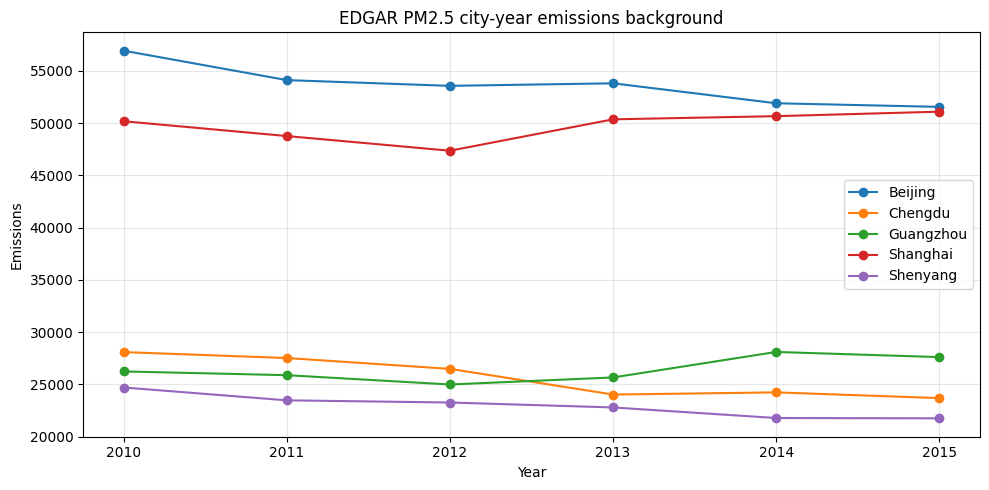


✓ Step 1b complete. EDGAR is used as city-year background information.


In [3]:

# =============================================================================
# STEP 1b — Aggregated EDGAR emissions integration
# =============================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("══ Step 1b  Aggregated EDGAR emissions integration ──────────────────")

def find_uploaded_file(*patterns: str) -> str:
    """Find an input file either in the working directory or /mnt/data."""
    search_dirs = [Path("."), Path("/mnt/data")]
    for pattern in patterns:
        for folder in search_dirs:
            matches = sorted(folder.glob(pattern))
            if matches:
                return str(matches[0])
    raise FileNotFoundError(f"Could not find any file matching: {patterns}")

edgar_path = find_uploaded_file("edgar_aggregated_emissions.csv", "edgar_aggregated_emissions*.csv")
print(f"  EDGAR file used: {edgar_path}")

def standardize_edgar(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    required = {"city", "year", "pollutant", "sector", "emissions"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"EDGAR file is missing required columns: {sorted(missing)}")

    df["city"] = df["city"].astype(str).str.strip()
    df["year"] = df["year"].astype(int)
    df["pollutant"] = (
        df["pollutant"].astype(str).str.strip().str.lower()
        .replace({"pm2.5": "pm2_5", "pm25": "pm2_5"})
    )
    df["sector"] = df["sector"].astype(str).str.strip().str.upper()
    df["emissions"] = pd.to_numeric(df["emissions"], errors="coerce")
    return df.dropna(subset=["emissions"])

edgar_long = standardize_edgar(pd.read_csv(edgar_path))

print(f"  Rows: {len(edgar_long):,}")
print(f"  Cities: {sorted(edgar_long['city'].unique())}")
print(f"  Years: {edgar_long['year'].min()}–{edgar_long['year'].max()}")
print(f"  Pollutants: {sorted(edgar_long['pollutant'].unique())}")
print(f"  Sectors: {sorted(edgar_long['sector'].unique())}")

display(
    edgar_long.groupby(["pollutant", "sector"], observed=True)
    .agg(rows=("emissions", "size"), mean_emissions=("emissions", "mean"), total_emissions=("emissions", "sum"))
    .round(2)
)

# Wide city-year feature matrix.
edgar_wide = (
    edgar_long
    .assign(feature=lambda d: "edgar_" + d["pollutant"] + "_" + d["sector"].str.lower())
    .pivot_table(index=["city", "year"], columns="feature", values="emissions", aggfunc="sum", fill_value=0)
    .reset_index()
)

# Pollutant totals.
for pollutant in sorted(edgar_long["pollutant"].unique()):
    cols = [c for c in edgar_wide.columns if c.startswith(f"edgar_{pollutant}_")]
    if cols:
        edgar_wide[f"edgar_{pollutant}_total"] = edgar_wide[cols].sum(axis=1)

# Sector totals.
for sector in sorted(edgar_long["sector"].unique()):
    sector_lower = sector.lower()
    cols = [c for c in edgar_wide.columns if c.endswith(f"_{sector_lower}")]
    if cols:
        edgar_wide[f"edgar_total_{sector_lower}"] = edgar_wide[cols].sum(axis=1)

EDGAR_CURRENT_FEATURES = [c for c in edgar_wide.columns if c.startswith("edgar_")]

# Lagged EDGAR features are safer in supervised prediction:
# 2015 can use 2014 emissions, avoiding contemporaneous test-year information.
edgar_lag = edgar_wide.copy()
edgar_lag["year"] = edgar_lag["year"] + 1
rename_lag = {c: f"{c}_lag1yr" for c in EDGAR_CURRENT_FEATURES}
edgar_lag = edgar_lag.rename(columns=rename_lag)
EDGAR_LAG_FEATURES = list(rename_lag.values())

# Merge current and lagged EDGAR into the panel. Current EDGAR is mainly for
# DAG/description; lagged EDGAR may be used in the optional Step 4 robustness check.
for panel_name in ["df_raw", "df_clean"]:
    if panel_name in globals():
        panel = globals()[panel_name].copy()
        panel["city"] = panel["city"].astype(str)
        panel = panel.merge(edgar_wide, on=["city", "year"], how="left")
        panel = panel.merge(edgar_lag[["city", "year"] + EDGAR_LAG_FEATURES], on=["city", "year"], how="left")
        globals()[panel_name] = panel
        print(f"  Merged EDGAR into {panel_name}: {panel.shape}")

print(f"  Current EDGAR features: {len(EDGAR_CURRENT_FEATURES)}")
print(f"  Lagged EDGAR features : {len(EDGAR_LAG_FEATURES)}")

# Diagnostic: city-year PM2.5 background emissions.
pm_total_col = "edgar_pm2_5_total"
if pm_total_col in edgar_wide.columns:
    plt.figure(figsize=(10, 5))
    for city in sorted(edgar_wide["city"].unique()):
        city_data = edgar_wide.loc[edgar_wide["city"] == city].sort_values("year")
        plt.plot(city_data["year"], city_data[pm_total_col], marker="o", label=city)
    plt.title("EDGAR PM2.5 city-year emissions background")
    plt.xlabel("Year")
    plt.ylabel("Emissions")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n✓ Step 1b complete. EDGAR is used as city-year background information.")

## 4. Planned Methods

### 4a. Causal Inference
- [x] Causal graph / DAG (DoWhy)
- [x] Backdoor adjustment

*Justification:*
Weather patterns directly determine localized heating demand (treatment) and alter air pollution dispersion capabilities (outcome). By building an explicit Directed Acyclic Graph (DAG) via the `DoWhy` framework, we can map structural assumptions and execute Backdoor Adjustment to block meteorological confounders (`TEMP`, `PRES`, `HUMI`), allowing us to isolate the true causal effect of the urban heating policy on PM2.5 levels.

### 4b. Supervised Learning
- [x] Decision Tree / Random Forest

*Justification:*
Atmospheric chemical configurations involve highly complex, non-linear physical thresholds (e.g., wind speed and temperature must pass specific boundaries to disperse smog). Random Forests are structurally optimized to capture these threshold phenomena and multi-variable interactions without forcing strict linear assumptions.

### 4c. Unsupervised Learning / Generative Models
- [x] K-Means clustering

*Justification:*
We will apply K-Means clustering to the clean meteorological features (`TEMP`, `DEWP`, `HUMI`, `PRES`, `Iws`) to discover latent 'Atmospheric Weather Regimes' across the cities. This helps economists determine if policy externalities are amplified under specific natural micro-climate profiles.


## 5. Evaluation Strategy

To ensure empirical validity, statistical robustness, and to protect against overfitting or spurious correlations, our mission will deploy a multi-tiered evaluation framework tailored specifically to each of the three analytical methodologies.

### 5a. Causal Inference Validation & Policy Robustness
Because causal claims cannot be verified using simple out-of-sample prediction metrics, we will evaluate our Average Treatment Effect (ATE) estimate through structural econometric diagnostics and algorithmic refutation frameworks using the `DoWhy` architecture:

1. **Statistical Inference and Panel Adjustments:** Rather than relying on naive standard errors, we will compute robust, clustered standard errors. Because air quality data exhibits strong spatial and temporal autocorrelation (shocks to air quality in one hour persist into subsequent hours), we will evaluate the statistical significance ($p$-values and 95% confidence intervals) by bootstrapping standard errors clustered at the `city` and `month` levels.
2. **Placebo Treatment Refutation:** We will run a structural validation test where the true policy variable (`heating_regime`) is replaced with an artificially generated, random assignment vector. If our backdoor adjustment graph is correctly specified and has blocked all active confounders, the newly calculated placebo treatment effect must collapse to 0 ($p > 0.05$). Any statistically significant non-zero effect will indicate the presence of unobserved target leakage or structural DAG misspecification.
3. **Random Common Cause Addition:** We will programmatically introduce an artificial independent random variable into our dataset as a simulated confounder. We will then rerun the backdoor linear regression estimation pipeline. The estimated causal coefficient for the winter heating policy must remain stable and invariant to this addition, confirming that our model is resilient to changes in atmospheric noise features.
4. **Data Subsets Refuter:** We will randomly drop 10% to 20% slices of our master panel data matrix and re-estimate the policy coefficient. The distribution of the resulting coefficients must remain tightly grouped around our primary ATE estimate, demonstrating that our causal insights are not driven by extreme seasonal outliers or anomaly hours in any single city.

### 5b. Supervised Learning Generalization Capacity
To assess how effectively our non-linear Random Forest Regressor models the transformation of physical weather matrices into air pollution, we will evaluate its performance using a rigorous validation pipeline:

1. **Data Splitting Strategy:** To simulate true out-of-sample forecasting, we will implement a chronological, time-based split rather than a completely randomized shuffle split. We will train our model on historical data spanning 2010 through 2014, and preserve the entire 2015 calendar year across all five cities as a strict holdout testing set. This ensures our evaluation strategy accounts for non-stationary trends, macro climate variations, and structural economic adjustments over time.
2. **Statistical Metrics:** Performance on the holdout test set will be quantified using three distinct metrics:
   * **Root Mean Squared Error (RMSE):** Measures prediction error magnitude while heavily penalizing large deviations, which is crucial because extreme, unexpected smog spikes carry the highest public health and economic costs ($\text{RMSE} = \sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$).
   * **Mean Absolute Error (MAE):** Provides a robust measure of median deviation, indicating the expected typical error margin during standard hourly operations ($\text{MAE} = \frac{1}{n}\sum|y_i - \hat{y}_i|$).
   * **Coefficient of Determination ($R^2$):** Measures the proportion of total hourly PM2.5 variance that can be successfully explained by our meteorological and policy features ($R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$).
3. **Baseline Comparison:** We will establish a clear benchmark for success by comparing our Random Forest model against a baseline Ordinary Least Squares (OLS) linear model and a naive lag-1 persistence model (predicting that the current hour's pollution equals the previous hour's pollution). Our machine learning model will be considered successful if it achieves a minimum 15% reduction in out-of-sample RMSE compared to these baseline benchmarks.

### 5c. Unsupervised Learning Profiling and Clustering Metrics
Because clustering lacks explicit target labels, we will utilize a blend of internal geometric metrics and external domain-driven evaluations to confirm the validity of our weather regimes:

1. **Geometric Optimization (The Elbow Method):** We will evaluate the internal compactness and separation of our climate groups by computing the **Within-Cluster Sum of Squares (Inertia)** across a range of potential cluster sizes ($K \in [2, 8]$). The optimal number of regimes ($K=4$) will be verified by identifying the structural "elbow" point where adding further clusters yields diminishing returns in variance explanation.
2. **Feature Scaler Validation:** Since clustering relies on Euclidean distance measurements, variables with larger absolute scales (such as atmospheric pressure, `PRES` $\approx 1000+$ hPa) could mathematically overwhelm smaller variables (such as temperature, `TEMP`). We will verify that our `StandardScaler` preprocessing pipeline achieves a uniform mean of 0 and variance of 1 across all features before clustering occurs.
3. **External Domain Validation (Target Separation Check):** While our K-Means model is trained strictly on natural weather features (`TEMP`, `DEWP`, `HUMI`, `PRES`, `Iws`) without ever seeing air pollution values, we will evaluate its real-world economic utility by mapping the *historical PM2.5 distributions* back onto each assigned cluster ID. If the unsupervised clusters reveal statistically distinct distributions of air quality (e.g., one cluster systematically groups severe smog events while another captures clean air days), it proves the algorithm has successfully extracted meaningful, latent environmental macro-regimes.


**Final implementation note:**  
The final analysis follows the approved proposal structure and includes all three required method blocks: causal inference, supervised learning, and unsupervised learning. During implementation, some details were refined for consistency and data quality. The heating-regime variable was corrected to the policy window from November 15 to March 15, Open-Meteo weather data were used for consistent meteorological controls, and EDGAR emissions were used as city-year background information rather than hourly emissions.

## 6. Work Plan

| Step | Owner | Description |
|------|-------|-------------|
| **1. Data collection & cleaning** | Danish | Code data ingestion across all 5 CSV files. Resolve latent missing entries (`NaN`) in target (`PM`) and meteorological features (`DEWP`, `Iws`) using forward-fill and strict drop-row filtration to ensure clean inputs for downstream algorithms. |
| **2. EDA** | Danish | Perform detailed Exploratory Data Analysis. Standardize climate features using `StandardScaler` to prevent scale dominance. Map regional urban boundaries to engineer the structural binary `heating_regime` policy indicator variable and plot baseline cross-city pollution trends. |
| **3. Causal inference block** | Oliver | Construct the explicit Directed Acyclic Graph (DAG) using the `DoWhy` framework. Define backdoor criteria to isolate the True Average Treatment Effect (ATE) of winter heating, adjusting for weather confounders (`TEMP`, `PRES`, `HUMI`), and compute robust, clustered standard errors. |
| **4. Supervised learning block** | Danish | Implement the non-shuffled chronological dataset split (training on 2010–2014, validation on 2015). Train and optimize a non-linear Random Forest Regressor to capture physical weather-smog interactions, and compute holdout performance statistics (RMSE, MAE, $R^2$). |
| **5. Unsupervised / generative block** | Oliver | Execute K-Means clustering optimization across a range of $K \in [2,8]$. Identify the geometric "elbow" point to establish 4 distinct micro-climate regimes, and map clusters back to localized historical PM2.5 distributions for domain validation. |
| **6. Synthesis & write-up** | Oliver | Execute Section 5 causal validation checks (Placebo Treatment and Random Common Cause refuters). Benchmark the machine learning model against OLS linear and Lag-1 baseline models. Cross-reference predictive vs. structural insights and finalize the proposal. |


---
## 7. Results *(complete for final submission)*


### 7a. Causal Inference

In [4]:

# =============================================================================
#  DAG assumptions and backdoor set
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("══ Step 3.1  DAG / structural assumptions ───────────────────────────")

DAG_EDGES = [
    ("City", "Heating regime"),
    ("City", "Emissions"),
    ("City", "PM2.5"),
    ("Calendar season", "Heating regime"),
    ("Calendar season", "Weather"),
    ("Calendar season", "Emissions"),
    ("Calendar season", "PM2.5"),
    ("Weather", "Heating regime"),
    ("Weather", "PM2.5"),
    ("Emissions", "PM2.5"),
    ("Heating regime", "PM2.5"),
]

print("Main DAG edges:")
for source, target in DAG_EDGES:
    print(f"  {source} → {target}")

BACKDOOR_SET = [
    "TEMP", "PRES", "HUMI", "DEWP", "Iws",
    "precipitation_log1p", "wind_sin", "wind_cos",
    "boundary_layer_height (m)", "cloud_cover (%)",
    "city fixed effects", "year fixed effects", "month fixed effects", "hour fixed effects",
]

print("\nTreatment : heating_regime")
print("Outcome   : PM")
print("Backdoor controls:")
for item in BACKDOOR_SET:
    print(f"  - {item}")

print(
    "\nNote: lagged PM is not included in the main causal regression because it may "
    "absorb persistence/mediation in pollution. Lagged PM is used in Step 4 prediction."
)

══ Step 3.1  DAG / structural assumptions ───────────────────────────
Main DAG edges:
  City → Heating regime
  City → Emissions
  City → PM2.5
  Calendar season → Heating regime
  Calendar season → Weather
  Calendar season → Emissions
  Calendar season → PM2.5
  Weather → Heating regime
  Weather → PM2.5
  Emissions → PM2.5
  Heating regime → PM2.5

Treatment : heating_regime
Outcome   : PM
Backdoor controls:
  - TEMP
  - PRES
  - HUMI
  - DEWP
  - Iws
  - precipitation_log1p
  - wind_sin
  - wind_cos
  - boundary_layer_height (m)
  - cloud_cover (%)
  - city fixed effects
  - year fixed effects
  - month fixed effects
  - hour fixed effects

Note: lagged PM is not included in the main causal regression because it may absorb persistence/mediation in pollution. Lagged PM is used in Step 4 prediction.


In [5]:

# =============================================================================
# Backdoor-adjusted regression with clustered standard errors
# =============================================================================

import statsmodels.formula.api as smf

print("══ Step 3.2  Backdoor-adjusted causal regression ─────────────────────")

df_causal = df_clean.copy()
df_causal["city"] = df_causal["city"].astype(str)

# Rename columns with spaces/symbols so statsmodels formulas are clean.
rename_for_causal = {
    "boundary_layer_height (m)": "boundary_layer_height_m",
    "cloud_cover (%)": "cloud_cover_pct",
}
df_causal = df_causal.rename(columns=rename_for_causal)

causal_required = [
    "PM", "heating_regime", "TEMP", "PRES", "HUMI", "DEWP", "Iws",
    "precipitation_log1p", "wind_sin", "wind_cos",
    "boundary_layer_height_m", "cloud_cover_pct",
    "city", "year", "month", "hour",
]
missing = [c for c in causal_required if c not in df_causal.columns]
assert not missing, f"Missing columns for causal block: {missing}"

df_causal = df_causal.dropna(subset=causal_required).copy()
df_causal["city_month"] = (
    df_causal["city"].astype(str) + "_" +
    df_causal["year"].astype(str) + "_" +
    df_causal["month"].astype(str).str.zfill(2)
)

causal_formula = """
PM ~ heating_regime
   + TEMP + PRES + HUMI + DEWP + Iws
   + precipitation_log1p + wind_sin + wind_cos
   + boundary_layer_height_m + cloud_cover_pct
   + C(city) + C(year) + C(month) + C(hour)
"""

causal_model = smf.ols(causal_formula, data=df_causal).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_causal["city_month"]}
)

coef = causal_model.params["heating_regime"]
se = causal_model.bse["heating_regime"]
pval = causal_model.pvalues["heating_regime"]
ci_low, ci_high = causal_model.conf_int().loc["heating_regime"]

print(f"Rows used: {len(df_causal):,}")
print(f"Cluster variable: city-month ({df_causal['city_month'].nunique():,} clusters)")
print("\nBackdoor-adjusted heating_regime estimate:")
print(f"  Coefficient: {coef: .4f}")
print(f"  Clustered SE: {se: .4f}")
print(f"  95% CI: [{ci_low: .4f}, {ci_high: .4f}]")
print(f"  p-value: {pval: .4f}")

print(
    "\nInterpretation: this estimates the adjusted difference in hourly PM2.5 for "
    "northern heating-regime hours, conditional on weather controls and fixed effects."
)

display(
    pd.DataFrame({
        "term": ["heating_regime"],
        "coef": [coef],
        "clustered_se": [se],
        "ci_low": [ci_low],
        "ci_high": [ci_high],
        "p_value": [pval],
    }).round(4)
)

══ Step 3.2  Backdoor-adjusted causal regression ─────────────────────
Rows used: 175,993
Cluster variable: city-month (250 clusters)

Backdoor-adjusted heating_regime estimate:
  Coefficient:  21.3290
  Clustered SE:  5.9895
  95% CI: [ 9.5898,  33.0683]
  p-value:  0.0004

Interpretation: this estimates the adjusted difference in hourly PM2.5 for northern heating-regime hours, conditional on weather controls and fixed effects.


,term,coef,clustered_se,ci_low,ci_high,p_value
0,heating_regime,21.329,5.9895,9.5898,33.0683,0.0004


══ Step 3.3  Placebo treatment refuter ───────────────────────────────
count    25.0000
mean     -0.0569
std       0.3598
min      -0.6379
25%      -0.2297
50%      -0.0962
75%       0.0544
max       0.7548
Name: placebo_coef, dtype: float64


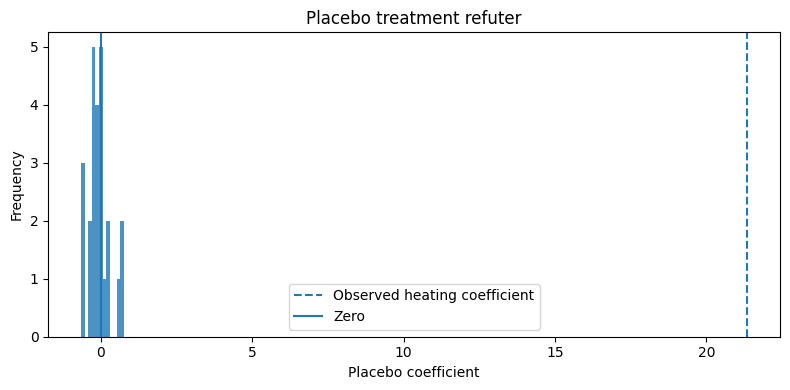

Interpretation: if placebo effects are centered near zero and far from the observed coefficient, the treatment result is less likely to be a pure artifact of the regression setup.


In [6]:

# =============================================================================
# Refuter 1: placebo treatment
# =============================================================================
# Randomly shuffle the treatment variable while keeping the rest of the panel unchanged.
# The placebo coefficient should not systematically reproduce the original result.

print("══ Step 3.3  Placebo treatment refuter ───────────────────────────────")

rng = np.random.default_rng(42)
n_placebo = 25
placebo_coefs = []

for i in range(n_placebo):
    df_placebo = df_causal.copy()
    df_placebo["placebo_heating"] = rng.permutation(df_placebo["heating_regime"].to_numpy())

    placebo_formula = causal_formula.replace("heating_regime", "placebo_heating", 1)
    placebo_model = smf.ols(placebo_formula, data=df_placebo).fit(
        cov_type="cluster",
        cov_kwds={"groups": df_placebo["city_month"]}
    )
    placebo_coefs.append(placebo_model.params["placebo_heating"])

placebo_summary = pd.Series(placebo_coefs, name="placebo_coef").describe()
print(placebo_summary.round(4))

plt.figure(figsize=(8, 4))
plt.hist(placebo_coefs, bins=12, alpha=0.8)
plt.axvline(coef, linestyle="--", label="Observed heating coefficient")
plt.axvline(0, linestyle="-", label="Zero")
plt.title("Placebo treatment refuter")
plt.xlabel("Placebo coefficient")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Interpretation: if placebo effects are centered near zero and far from the "
    "observed coefficient, the treatment result is less likely to be a pure artifact "
    "of the regression setup."
)

In [7]:

# =============================================================================
# Refuter 2: random common cause
# =============================================================================
# Add an irrelevant random variable. The heating coefficient should remain stable.

print("══ Step 3.4  Random common cause refuter ─────────────────────────────")

df_random_cc = df_causal.copy()
rng = np.random.default_rng(123)
df_random_cc["random_common_cause"] = rng.normal(size=len(df_random_cc))

random_cc_formula = causal_formula + " + random_common_cause"
random_cc_model = smf.ols(random_cc_formula, data=df_random_cc).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_random_cc["city_month"]}
)

coef_random_cc = random_cc_model.params["heating_regime"]
change = coef_random_cc - coef

print(f"Original heating coefficient      : {coef: .4f}")
print(f"With random common cause          : {coef_random_cc: .4f}")
print(f"Absolute coefficient change       : {change: .4f}")
print(f"Relative coefficient change       : {100 * change / coef if coef != 0 else np.nan: .2f}%")

print(
    "\nInterpretation: a small change suggests the heating estimate is not very sensitive "
    "to adding irrelevant noise."
)

══ Step 3.4  Random common cause refuter ─────────────────────────────
Original heating coefficient      :  21.3290
With random common cause          :  21.3317
Absolute coefficient change       :  0.0026
Relative coefficient change       :  0.01%

Interpretation: a small change suggests the heating estimate is not very sensitive to adding irrelevant noise.


══ Step 3.5  Data-subset refuter ─────────────────────────────────────
count    25.0000
mean     22.2831
std       3.0309
min      16.0425
25%      19.7122
50%      22.1797
75%      24.7519
max      27.8501
Name: subset_coef, dtype: float64


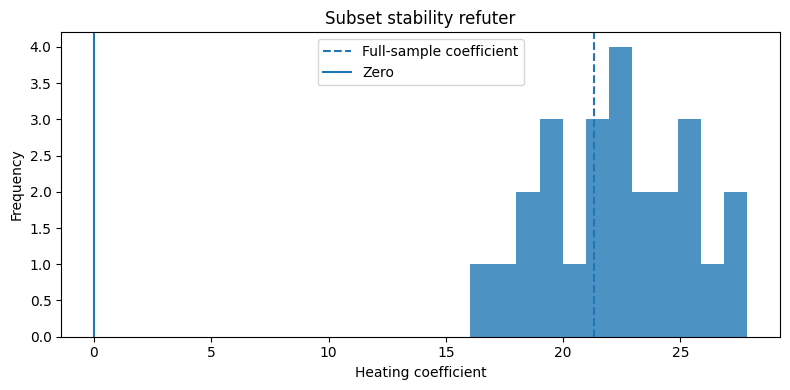

Interpretation: if the subset coefficients remain in the same general range, the result is less dependent on one small part of the panel.


In [8]:

# =============================================================================
# Refuter 3: data subset stability
# =============================================================================
# Estimate the same model on repeated 80% city-month block subsamples.

print("══ Step 3.5  Data-subset refuter ─────────────────────────────────────")

rng = np.random.default_rng(321)
blocks = df_causal["city_month"].unique()
n_subsets = 25
subset_coefs = []

for i in range(n_subsets):
    sampled_blocks = rng.choice(blocks, size=int(0.8 * len(blocks)), replace=False)
    df_subset = df_causal[df_causal["city_month"].isin(sampled_blocks)].copy()

    subset_model = smf.ols(causal_formula, data=df_subset).fit(
        cov_type="cluster",
        cov_kwds={"groups": df_subset["city_month"]}
    )
    subset_coefs.append(subset_model.params["heating_regime"])

subset_summary = pd.Series(subset_coefs, name="subset_coef").describe()
print(subset_summary.round(4))

plt.figure(figsize=(8, 4))
plt.hist(subset_coefs, bins=12, alpha=0.8)
plt.axvline(coef, linestyle="--", label="Full-sample coefficient")
plt.axvline(0, linestyle="-", label="Zero")
plt.title("Subset stability refuter")
plt.xlabel("Heating coefficient")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Interpretation: if the subset coefficients remain in the same general range, "
    "the result is less dependent on one small part of the panel."
)

In [9]:

# =============================================================================
# Optional causal sensitivity with lagged EDGAR emissions
# =============================================================================
# This checks whether city-year background emissions change the heating coefficient.
# It is optional because EDGAR is annual/city-level, not true hourly emissions.

print("══ Step 3.6  EDGAR sensitivity for causal estimate ───────────────────")

if "EDGAR_LAG_FEATURES" not in globals() or len(EDGAR_LAG_FEATURES) == 0:
    print("EDGAR lag features are not available. Skipping.")
else:
    edgar_causal_cols = [
        c for c in EDGAR_LAG_FEATURES
        if c in df_causal.columns and df_causal[c].notna().any()
    ]

    if not edgar_causal_cols:
        print("No non-missing lagged EDGAR features available in df_causal. Skipping.")
    else:
        # Keep only a small, interpretable subset if available.
        preferred = [
            "edgar_pm2_5_total_lag1yr",
            "edgar_total_transport_lag1yr",
            "edgar_total_buildings_lag1yr",
            "edgar_total_power_industry_lag1yr",
        ]
        edgar_use = [c for c in preferred if c in edgar_causal_cols]
        if not edgar_use:
            edgar_use = edgar_causal_cols[:4]

        edgar_formula = causal_formula + " + " + " + ".join(edgar_use)

        df_edgar_causal = df_causal.dropna(subset=edgar_use).copy()
        edgar_causal_model = smf.ols(edgar_formula, data=df_edgar_causal).fit(
            cov_type="cluster",
            cov_kwds={"groups": df_edgar_causal["city_month"]}
        )

        coef_edgar = edgar_causal_model.params["heating_regime"]
        print(f"EDGAR features used: {edgar_use}")
        print(f"Original causal coefficient      : {coef: .4f}")
        print(f"With lagged EDGAR controls       : {coef_edgar: .4f}")
        print(f"Coefficient change               : {coef_edgar - coef: .4f}")

        display(
            pd.DataFrame({
                "model": ["main backdoor model", "with lagged EDGAR controls"],
                "heating_coef": [coef, coef_edgar],
            }).round(4)
        )

        print(
            "\nInterpretation: EDGAR controls are used only as annual background emission "
            "sensitivity variables. They do not replace the main city-hour weather panel."
        )

══ Step 3.6  EDGAR sensitivity for causal estimate ───────────────────
EDGAR features used: ['edgar_pm2_5_total_lag1yr', 'edgar_total_transport_lag1yr', 'edgar_total_buildings_lag1yr', 'edgar_total_power_industry_lag1yr']
Original causal coefficient      :  21.3290
With lagged EDGAR controls       :  20.7523
Coefficient change               : -0.5768


,model,heating_coef
0,main backdoor model,21.3290
1,with lagged EDGAR controls,20.7523



Interpretation: EDGAR controls are used only as annual background emission sensitivity variables. They do not replace the main city-hour weather panel.


### 7b. Supervised Learning

══ 4.1  Feature engineering and chronological split ─────────────────
  Tuning-fit years observed : [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013)]
  Validation years observed : [np.int64(2014)]
  Final train years observed: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014)]
  Test years observed       : [np.int64(2015)]
  Tuning fit set (2010–2013): 84,008 rows
  Validation set (2014)     : 43,662 rows
  Final train (2010–2014)   : 127,670 rows
  Final test (2015)         : 43,677 rows
  Number of model features  : 73
  ✓ 2015 remains untouched until final evaluation.

══ 4.1b  2015 structural anomaly check ──────────────────────────────
  KS test — PM2.5 distribution, train vs 2015 test (per city):
    Beijing   : KS=0.079, p=0.0000  [SHIFT (p<0.05)]
    Shenyang  : KS=0.053, p=0.0000  [SHIFT (p<0.05)]
    Shanghai  : KS=0.035, p=0.0000  [SHIFT (p<0.05)]
    Chengdu   : KS=0.160, p=0.0000  [SHIFT (p<0.05)]
    Guangzhou : KS=0.217, p=0.0

,train_mean,test_2015_mean,pct_diff
TEMP,15.513,15.998,3.1
PRES,1015.000,1015.336,0.0
HUMI,66.204,68.303,3.2
DEWP,8.277,9.330,12.7
Iws,9.515,9.683,1.8
wind_sin,0.055,0.047,-13.4
wind_cos,0.100,0.086,-13.7
boundary_layer_height (m),499.870,496.506,-0.7
cloud_cover (%),54.689,59.367,8.6
precipitation_log1p,0.067,0.073,8.9


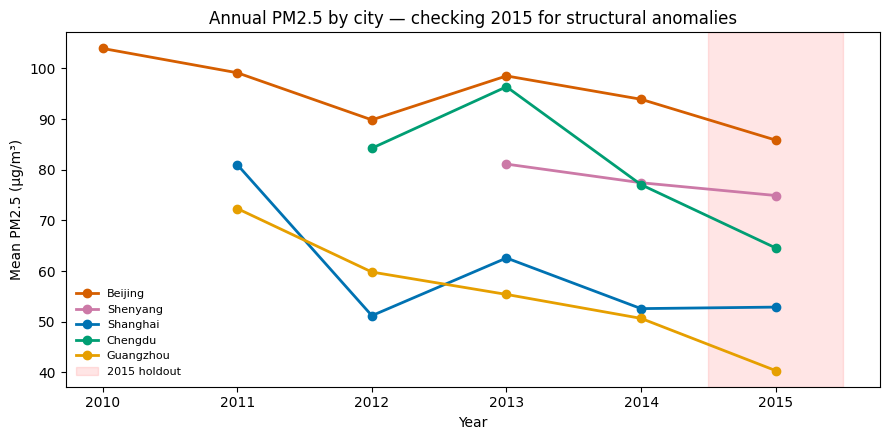


  → 5/5 cities show a statistically significant PM distribution shift in 2015.
  → Treat the 2015 test as a difficult chronological holdout, not an IID random split.

══ 4.1c  2015 anomaly magnitude screen ──────────────────────────────


,city,feature,train_2010_2014_mean,test_2015_mean,z_vs_train_years,flag
0,Beijing,PM,97.082,85.859,-2.084,EXTREME
36,Chengdu,PM,85.901,64.562,-2.184,EXTREME
48,Guangzhou,PM,59.545,40.339,-2.062,EXTREME
23,Shenyang,wind_gusts_10m (km/h),23.672,24.186,2.249,EXTREME
4,Beijing,DEWP,0.794,2.138,1.751,within range
3,Beijing,HUMI,51.405,53.737,1.412,within range
5,Beijing,Iws,7.259,7.092,-0.904,within range
2,Beijing,PRES,1016.369,1016.728,0.620,within range
1,Beijing,TEMP,12.130,12.966,1.019,within range
8,Beijing,boundary_layer_height (m),539.102,533.099,-0.187,within range


  → Extreme city-feature deviations flagged: 4
  → If many 2015 extremes are flagged, report 2015 as an out-of-distribution holdout.

══ 4.2  Baselines: Lag persistence and OLS ──────────────────────────
  Lag-1 persistence RMSE : 13.027
  Lag-24 persistence RMSE: 63.522
  OLS engineered RMSE    : 12.137
  Ridge engineered RMSE  : 12.134  (alpha=336)

══ 4.3  Random Forest tuning using 2014 validation ──────────────────
  Candidate 1: validation RMSE=13.601 | {'n_estimators': 250, 'max_depth': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
  Candidate 2: validation RMSE=13.265 | {'n_estimators': 250, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
  Candidate 3: validation RMSE=12.803 | {'n_estimators': 250, 'max_depth': 25, 'min_samples_leaf': 3, 'max_features': 0.6}
  Candidate 4: validation RMSE=12.717 | {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 10, 'max_features': 0.6}
  Candidate 5: validation RMSE=12.971 | {'n_estimators': 300, 'max_depth': 

,candidate,n_estimators,max_depth,min_samples_leaf,max_features,valid_2014_RMSE
0,4,300,NaN,10,0.6,12.717
1,3,250,25.0,3,0.6,12.803
2,5,300,18.0,10,1.0,12.971
3,2,250,18.0,5,sqrt,13.265
4,1,250,12.0,5,sqrt,13.601


  Selected RF params from 2014 validation: {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 10, 'max_features': 0.6}

  Final RF 2015 RMSE: 12.680

══ 4.4  Delta-PM models: predicting change from lag-1 ───────────────
  Delta RF candidate 1: validation RMSE=12.628 | {'n_estimators': 250, 'max_depth': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
  Delta RF candidate 2: validation RMSE=12.498 | {'n_estimators': 250, 'max_depth': 18, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
  Delta RF candidate 3: validation RMSE=12.345 | {'n_estimators': 250, 'max_depth': 25, 'min_samples_leaf': 3, 'max_features': 0.6}
  Delta RF candidate 4: validation RMSE=12.314 | {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 10, 'max_features': 0.6}
  Delta RF candidate 5: validation RMSE=12.402 | {'n_estimators': 300, 'max_depth': 18, 'min_samples_leaf': 10, 'max_features': 1.0}

  Delta RF validation results:


...


  Bootstrap probability of meeting the proposal success threshold:
    P(RF engineered beats Lag-1 by ≥15%): 0.000
    P(RF engineered beats OLS by ≥15%): 0.000
    P(RF delta beats Lag-1 by ≥15%): 0.003
    P(RF delta beats OLS by ≥15%): 0.000
    P(HGB engineered beats Lag-1 by ≥15%): 0.000
    P(HGB engineered beats OLS by ≥15%): 0.000
    P(HGB delta beats Lag-1 by ≥15%): 0.005
    P(HGB delta beats OLS by ≥15%): 0.000

══ 4.7  OLS two-way clustered standard errors ───────────────────────


c:\Users\ahmad\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


,coef,std_err_city_month_clustered,t,p_value
const,58.5434,23.9905,2.4403,0.0712
PM_lag1,0.2997,0.0098,30.5654,0.0000
PM_lag2,0.0235,0.0331,0.7097,0.5171
PM_lag24,0.1474,0.0049,29.8065,0.0000
PM_roll24,0.0543,0.0085,6.3849,0.0031
PM_diff24,0.1523,0.0052,29.0879,0.0000
TEMP,-0.0214,0.3738,-0.0571,0.9572
TEMP_lag1,-0.5178,0.5091,-1.0171,0.3666
HUMI,0.1024,0.1133,0.9039,0.4171
Iws,-0.1981,0.0926,-2.1381,0.0993


  ✓ Two-way clustered OLS standard errors computed by city and month.
  Note: only five city clusters exist, so coefficient inference remains cautious;
  the city-month block bootstrap above is the main RMSE uncertainty check.

══ 4.8  Feature importance — Random Forest ──────────────────────────


,importance
PM_lag1,0.6064
PM_roll3,0.2340
PM_lag2,0.0755
PM_roll6,0.0341
PM_lag3,0.0129
PM_diff1,0.0088
PM_diff3,0.0037
PM_roll12,0.0027
PM_lag6,0.0017
PM_roll24,0.0011


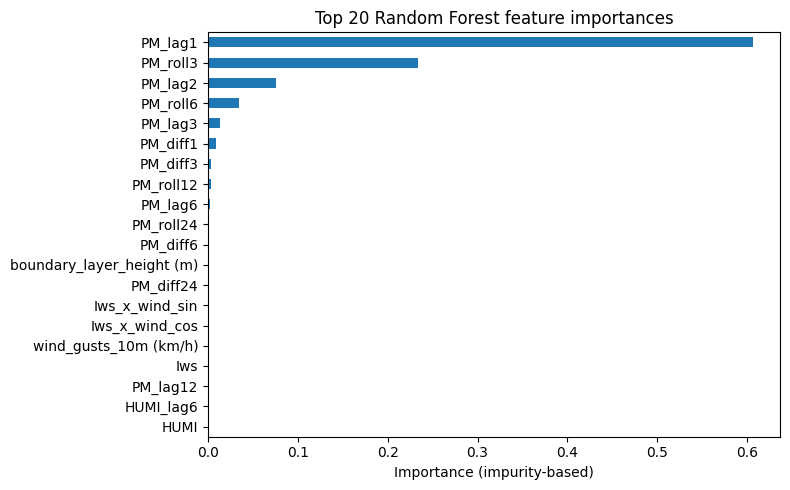


══ 4.9  Predicted vs actual PM2.5 — sample week by city ─────────────


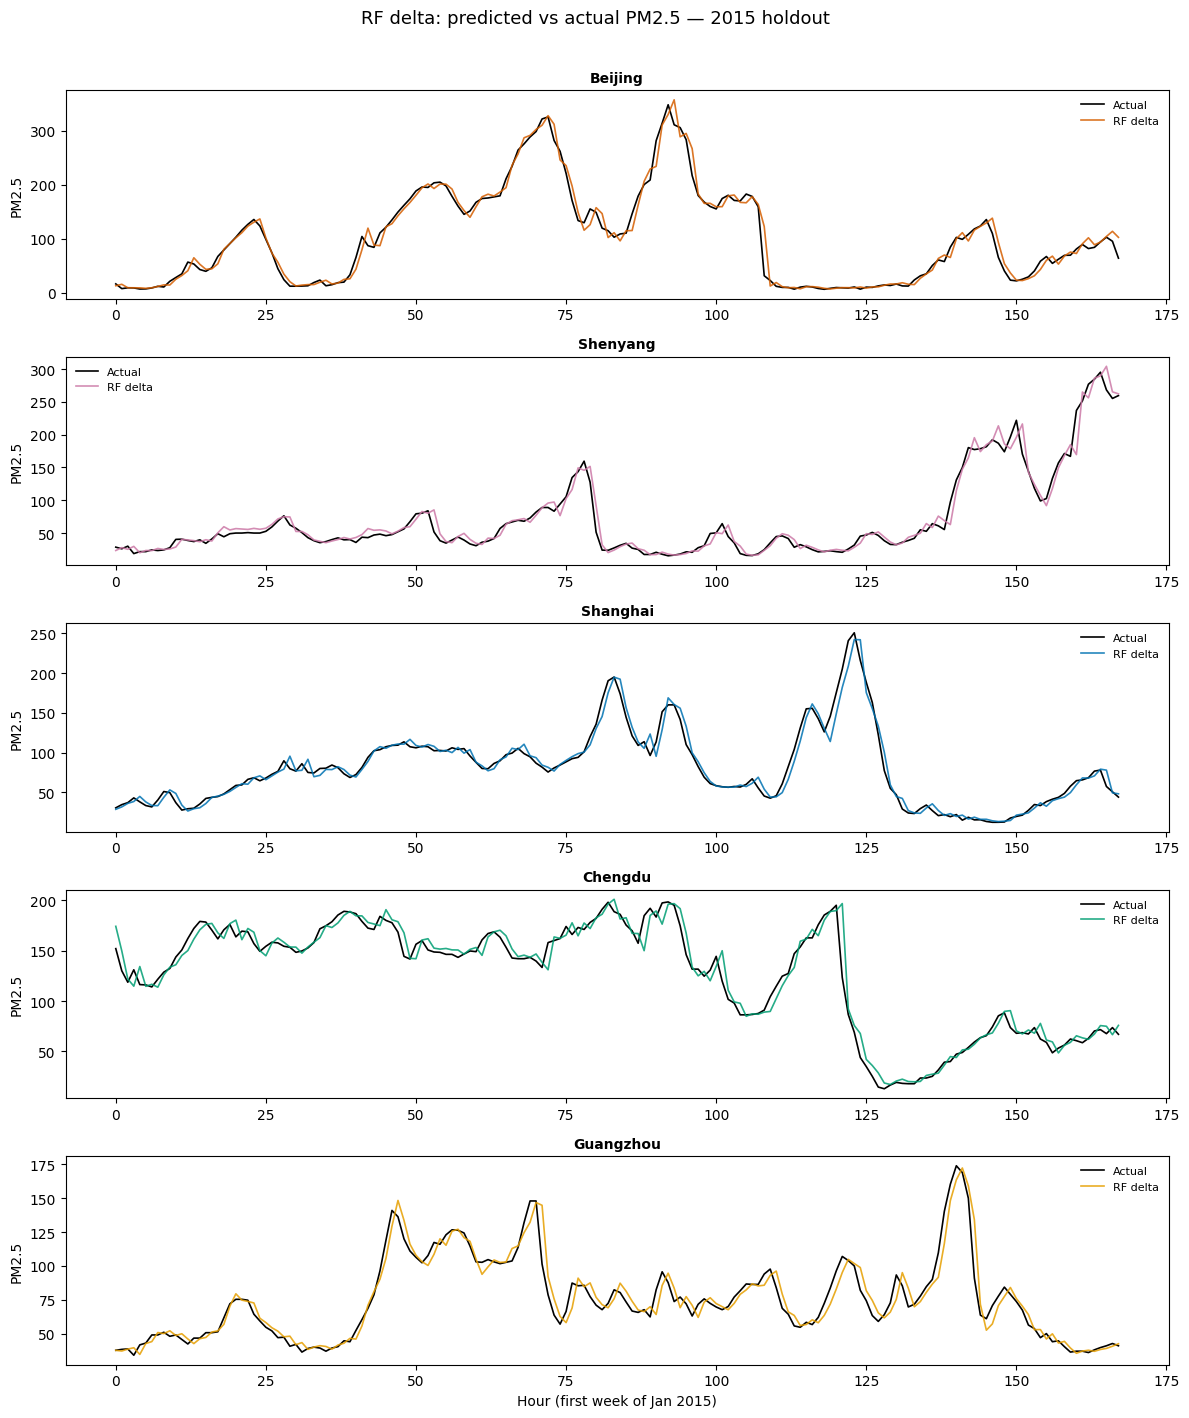


══ 4.10  Residual diagnostics — best RF-style model ─────────────────


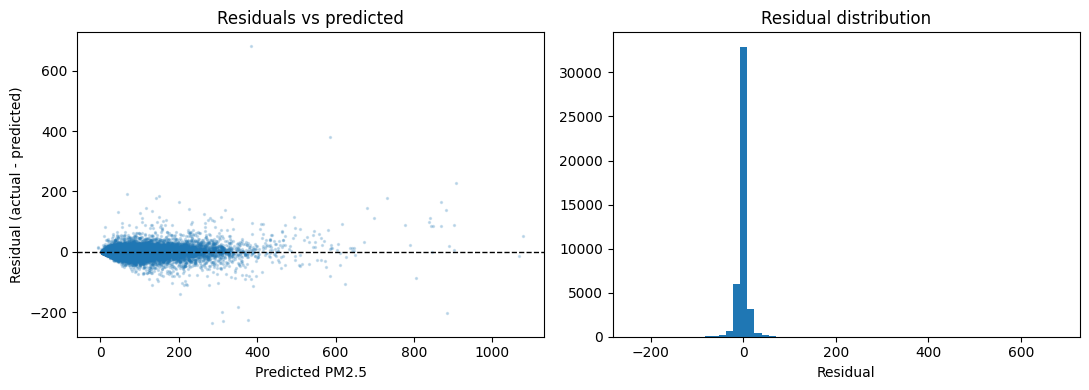

  Residual mean : -0.462
  Residual std  : 11.640

  Note: 5 cities show a 2015 PM distribution shift.
  If residual bias remains, discuss part of the error as distribution shift rather than pure model failure.

✓ Step 4 complete.
  Main objects available: results, rf_tuning_df, rf_delta_tuning_df, hgb_tuning_df, hgb_delta_tuning_df,
  bootstrap_df, bootstrap_summary, ks_df, struct_check, anomaly_df, rf, hgb, ols, ridge, rf_delta, hgb_delta,
  and clustered_ols_table if available.


In [10]:
# =============================================================================
# Improved Supervised Learning: RF vs OLS vs Lag Baselines
# =============================================================================

import itertools

CITIES = ["Beijing", "Shenyang", "Shanghai", "Chengdu", "Guangzhou"]
CITY_COLORS = {
    "Beijing": "#D55E00", "Shenyang": "#CC79A7",
    "Shanghai": "#0072B2", "Chengdu": "#009E73",
    "Guangzhou": "#E69F00",
}
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import ks_2samp

# =============================================================================
# 4.1  FEATURE ENGINEERING WITHOUT 2015 LEAKAGE
# =============================================================================
print("══ 4.1  Feature engineering and chronological split ─────────────────")

# Work on a copy so Step 1/2 outputs remain unchanged.
# Use df_raw rather than the already row-dropped df_clean so shifts represent
# true adjacent hourly records. Missing targets/features are removed only after
# lag and rolling variables have been constructed.
df_model = df_raw.copy()

# Sort before any lag/rolling features. Lags are calculated within city only.
df_model = df_model.sort_values(["city", "year", "month", "day", "hour"]).reset_index(drop=True)

# Defensive checks for columns created in Step 1.
required_cols = [
    "city", "season", "year", "month", "day", "hour", "PM",
    "TEMP", "PRES", "HUMI", "DEWP", "Iws",
    "wind_sin", "wind_cos", "wind_dir_missing", "heating_regime",
    "boundary_layer_height (m)", "cloud_cover (%)", "precipitation_log1p",
    "wind_gusts_10m (km/h)",
]
missing_cols = [c for c in required_cols if c not in df_model.columns]
assert not missing_cols, f"Missing required columns from Step 1/2: {missing_cols}"

# Multiple PM lags. These are legitimate because they use only past PM values.
LAG_HOURS = [1, 2, 3, 6, 12, 24]
g = df_model.groupby("city", observed=True)["PM"]
for lag in LAG_HOURS:
    df_model[f"PM_lag{lag}"] = g.shift(lag)

# Rolling summaries based only on past values. shift(1) prevents current-hour leakage.
ROLL_WINDOWS = [3, 6, 12, 24]
for window in ROLL_WINDOWS:
    df_model[f"PM_roll{window}"] = (
        g.transform(lambda s, w=window: s.shift(1).rolling(window=w, min_periods=w).mean())
    )

# PM trend / momentum features. These use only already-lagged PM values, so they do
# not leak the current target. They help models learn whether pollution is rising or falling.
df_model["PM_diff1"] = df_model["PM_lag1"] - df_model["PM_lag2"]
df_model["PM_diff3"] = df_model["PM_lag1"] - df_model["PM_lag3"]
df_model["PM_diff6"] = df_model["PM_lag1"] - df_model["PM_lag6"]
df_model["PM_diff24"] = df_model["PM_lag1"] - df_model["PM_lag24"]

# Lagged weather and wind conditions. These are safe because each value is shifted
# within city before prediction. The short lag set keeps the extension defensible and
# avoids adding dozens of arbitrary features after seeing 2015 results.
WEATHER_LAG_BASE = [
    "TEMP", "PRES", "HUMI", "DEWP", "Iws", "wind_sin", "wind_cos",
    "boundary_layer_height (m)", "cloud_cover (%)",
    "precipitation_log1p", "wind_gusts_10m (km/h)",
]
WEATHER_LAG_HOURS = [1, 3, 6]
for col in WEATHER_LAG_BASE:
    cg = df_model.groupby("city", observed=True)[col]
    for lag in WEATHER_LAG_HOURS:
        df_model[f"{col}_lag{lag}"] = cg.shift(lag)

# Cyclic temporal features. This avoids treating hour 23 and hour 0 as far apart.
df_model["hour_sin"] = np.sin(2 * np.pi * df_model["hour"] / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model["hour"] / 24)
df_model["month_sin"] = np.sin(2 * np.pi * (df_model["month"] - 1) / 12)
df_model["month_cos"] = np.cos(2 * np.pi * (df_model["month"] - 1) / 12)

# Wind-direction interactions: direction matters more when wind speed is non-zero.
df_model["Iws_x_wind_sin"] = df_model["Iws"] * df_model["wind_sin"]
df_model["Iws_x_wind_cos"] = df_model["Iws"] * df_model["wind_cos"]

LAG_FEATURES = [f"PM_lag{lag}" for lag in LAG_HOURS]
ROLL_FEATURES = [f"PM_roll{window}" for window in ROLL_WINDOWS]
PM_TREND_FEATURES = ["PM_diff1", "PM_diff3", "PM_diff6", "PM_diff24"]
WEATHER_FEATURES = [
    "TEMP", "PRES", "HUMI", "DEWP", "Iws",
    "wind_sin", "wind_cos", "wind_dir_missing",
    "Iws_x_wind_sin", "Iws_x_wind_cos",
    "boundary_layer_height (m)", "cloud_cover (%)",
    "precipitation_log1p", "wind_gusts_10m (km/h)",
]
WEATHER_LAG_FEATURES = [
    f"{col}_lag{lag}" for col in WEATHER_LAG_BASE for lag in WEATHER_LAG_HOURS
]
TIME_FEATURES = ["hour_sin", "hour_cos", "month_sin", "month_cos", "heating_regime"]
BASE_NUMERIC_FEATURES = (
    LAG_FEATURES + ROLL_FEATURES + PM_TREND_FEATURES +
    WEATHER_FEATURES + WEATHER_LAG_FEATURES + TIME_FEATURES
)
TARGET = "PM"

# Drop rows where lag/rolling construction creates missing values. This mainly removes
# the first 24 hours per city, not arbitrary test-year observations.
df_model = df_model.dropna(subset=BASE_NUMERIC_FEATURES + [TARGET]).reset_index(drop=True)

# Add city and season fixed-effect dummies for both OLS and RF. This is a fairer
# comparison because both models receive the same city/season information.
df_enc = pd.get_dummies(df_model, columns=["city", "season"], drop_first=True)
DUMMY_FEATURES = sorted([c for c in df_enc.columns if c.startswith("city_") or c.startswith("season_")])
MODEL_FEATURES = BASE_NUMERIC_FEATURES + DUMMY_FEATURES

# Chronological split design:
# - 2010–2013: fitting during RF hyperparameter tuning
# - 2014: validation for choosing RF hyperparameters
# - 2010–2014: final training after tuning
# - 2015: final untouched test set
train_tune_df = df_enc.loc[df_enc["year"] <= 2013].copy()
valid_df      = df_enc.loc[df_enc["year"] == 2014].copy()
train_df      = df_enc.loc[df_enc["year"] <= 2014].copy()
test_df       = df_enc.loc[df_enc["year"] == 2015].copy()

# Keep chronological order after splitting.
sort_cols = ["year", "month", "day", "hour"]
train_tune_df = train_tune_df.sort_values(sort_cols).reset_index(drop=True)
valid_df      = valid_df.sort_values(sort_cols).reset_index(drop=True)
train_df      = train_df.sort_values(sort_cols).reset_index(drop=True)
test_df       = test_df.sort_values(sort_cols).reset_index(drop=True)

EXPECTED_TRAIN_TUNE_YEARS = {2010, 2011, 2012, 2013}
EXPECTED_VALID_YEARS = {2014}
EXPECTED_TRAIN_YEARS = {2010, 2011, 2012, 2013, 2014}
EXPECTED_TEST_YEARS = {2015}

def observed_years(frame):
    return set(frame["year"].dropna().astype(int).unique())

print(f"  Tuning-fit years observed : {sorted(observed_years(train_tune_df))}")
print(f"  Validation years observed : {sorted(observed_years(valid_df))}")
print(f"  Final train years observed: {sorted(observed_years(train_df))}")
print(f"  Test years observed       : {sorted(observed_years(test_df))}")

assert observed_years(train_tune_df).issubset(EXPECTED_TRAIN_TUNE_YEARS)
assert observed_years(valid_df) == EXPECTED_VALID_YEARS
assert observed_years(train_df).issubset(EXPECTED_TRAIN_YEARS)
assert observed_years(test_df) == EXPECTED_TEST_YEARS
assert train_df["year"].max() < test_df["year"].min(), "Temporal leakage: train overlaps test."

X_tune, y_tune = train_tune_df[MODEL_FEATURES], train_tune_df[TARGET]
X_valid, y_valid = valid_df[MODEL_FEATURES], valid_df[TARGET]
X_train, y_train = train_df[MODEL_FEATURES], train_df[TARGET]
X_test, y_test = test_df[MODEL_FEATURES], test_df[TARGET]

print(f"  Tuning fit set (2010–2013): {len(train_tune_df):,} rows")
print(f"  Validation set (2014)     : {len(valid_df):,} rows")
print(f"  Final train (2010–2014)   : {len(train_df):,} rows")
print(f"  Final test (2015)         : {len(test_df):,} rows")
print(f"  Number of model features  : {len(MODEL_FEATURES)}")
print("  ✓ 2015 remains untouched until final evaluation.")


# =============================================================================
# 4.1b  STRUCTURAL-BREAK CHECK — 2015 vs 2010–2014
# =============================================================================
print("\n══ 4.1b  2015 structural anomaly check ──────────────────────────────")

# Use the non-dummied model frame for human-readable city labels.
train_plain = df_model.loc[df_model["year"] <= 2014].copy()
test_plain = df_model.loc[df_model["year"] == 2015].copy()

print("  KS test — PM2.5 distribution, train vs 2015 test (per city):")
ks_results = []
for city in CITIES:
    train_pm = train_plain.loc[train_plain["city"] == city, "PM"]
    test_pm  = test_plain.loc[test_plain["city"] == city, "PM"]
    stat, pval = ks_2samp(train_pm, test_pm)
    flag = "SHIFT (p<0.05)" if pval < 0.05 else "ok"
    ks_results.append({"city": city, "KS_stat": stat, "p_value": pval, "flag": flag})
    print(f"    {city:10s}: KS={stat:.3f}, p={pval:.4f}  [{flag}]")
ks_df = pd.DataFrame(ks_results)

BASE_WEATHER_FOR_SHIFT = [
    "TEMP", "PRES", "HUMI", "DEWP", "Iws", "wind_sin", "wind_cos",
    "boundary_layer_height (m)", "cloud_cover (%)",
    "precipitation_log1p", "wind_gusts_10m (km/h)",
]
struct_check = pd.DataFrame({
    "train_mean": train_plain[BASE_WEATHER_FOR_SHIFT].mean(),
    "test_2015_mean": test_plain[BASE_WEATHER_FOR_SHIFT].mean(),
})
denominator = struct_check["train_mean"].replace(0, np.nan)
struct_check["pct_diff"] = ((struct_check["test_2015_mean"] - struct_check["train_mean"]) / denominator * 100).round(1)
print("\n  Mean comparison — weather features, train vs 2015:")
display(struct_check.round(3))

annual_check = df_model.groupby(["city", "year"], observed=True)["PM"].mean().reset_index()
fig, ax = plt.subplots(figsize=(9, 4.5))
for city in CITIES:
    d = annual_check[annual_check["city"] == city]
    ax.plot(d["year"], d["PM"], marker="o", lw=2, color=CITY_COLORS[city], label=city)
ax.axvspan(2014.5, 2015.5, alpha=0.1, color="red", label="2015 holdout")
ax.set_xlabel("Year"); ax.set_ylabel("Mean PM2.5 (µg/m³)")
ax.set_title("Annual PM2.5 by city — checking 2015 for structural anomalies")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

n_shift_cities = int((ks_df["p_value"] < 0.05).sum())
print(f"\n  → {n_shift_cities}/{len(CITIES)} cities show a statistically significant PM distribution shift in 2015.")
print("  → Treat the 2015 test as a difficult chronological holdout, not an IID random split.")


# =============================================================================
# 4.1c  2015 ANOMALY MAGNITUDE SCREEN
# =============================================================================
print("\n══ 4.1c  2015 anomaly magnitude screen ──────────────────────────────")

ANOMALY_FEATURES = ["PM"] + BASE_WEATHER_FOR_SHIFT
annual_feature_means = df_model.groupby(["city", "year"], observed=True)[ANOMALY_FEATURES].mean().reset_index()

anomaly_rows = []
for city in CITIES:
    city_annual = annual_feature_means.loc[annual_feature_means["city"] == city]
    train_annual = city_annual.loc[city_annual["year"] <= 2014]
    test_annual = city_annual.loc[city_annual["year"] == 2015]
    if test_annual.empty:
        continue
    for feature in ANOMALY_FEATURES:
        train_vals = train_annual[feature].dropna()
        test_val = float(test_annual[feature].iloc[0])
        train_mean = float(train_vals.mean())
        train_std = float(train_vals.std(ddof=1))
        z_score = np.nan if train_std == 0 or np.isnan(train_std) else (test_val - train_mean) / train_std
        flag = "EXTREME" if pd.notna(z_score) and abs(z_score) >= 2.0 else "within range"
        anomaly_rows.append({
            "city": city,
            "feature": feature,
            "train_2010_2014_mean": train_mean,
            "test_2015_mean": test_val,
            "z_vs_train_years": z_score,
            "flag": flag,
        })

anomaly_df = pd.DataFrame(anomaly_rows)
display(anomaly_df.sort_values(["flag", "city", "feature"]).round(3))
n_extreme = int((anomaly_df["flag"] == "EXTREME").sum())
print(f"  → Extreme city-feature deviations flagged: {n_extreme}")
print("  → If many 2015 extremes are flagged, report 2015 as an out-of-distribution holdout.")


# =============================================================================
# 4.2  BASELINE MODELS
# =============================================================================
print("\n══ 4.2  Baselines: Lag persistence and OLS ──────────────────────────")

def metrics(y_true, y_pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
    }

# Naive persistence baselines.
lag1_pred = test_df["PM_lag1"].to_numpy()
lag24_pred = test_df["PM_lag24"].to_numpy()
lag1_metrics = metrics(y_test, lag1_pred)
lag24_metrics = metrics(y_test, lag24_pred)

# OLS on the engineered feature set.
ols = LinearRegression()
ols.fit(X_train, y_train)
ols_pred = ols.predict(X_test)
ols_metrics = metrics(y_test, ols_pred)

# Ridge can be useful when many lag/rolling features are strongly correlated.
ridge = RidgeCV(alphas=np.logspace(-3, 4, 20))
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge_metrics = metrics(y_test, ridge_pred)

print(f"  Lag-1 persistence RMSE : {lag1_metrics['RMSE']:.3f}")
print(f"  Lag-24 persistence RMSE: {lag24_metrics['RMSE']:.3f}")
print(f"  OLS engineered RMSE    : {ols_metrics['RMSE']:.3f}")
print(f"  Ridge engineered RMSE  : {ridge_metrics['RMSE']:.3f}  (alpha={ridge.alpha_:.4g})")


# =============================================================================
# 4.3  RANDOM FOREST TUNING ON 2014 VALIDATION ONLY
# =============================================================================
print("\n══ 4.3  Random Forest tuning using 2014 validation ──────────────────")

# This grid is intentionally modest to avoid tuning until the 2015 result looks good.
# We choose parameters on 2014 only, then refit once on 2010–2014 and evaluate once on 2015.
RF_PARAM_GRID = [
    {"n_estimators": 250, "max_depth": 12,   "min_samples_leaf": 5,  "max_features": "sqrt"},
    {"n_estimators": 250, "max_depth": 18,   "min_samples_leaf": 5,  "max_features": "sqrt"},
    {"n_estimators": 250, "max_depth": 25,   "min_samples_leaf": 3,  "max_features": 0.60},
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 10, "max_features": 0.60},
    {"n_estimators": 300, "max_depth": 18,   "min_samples_leaf": 10, "max_features": 1.00},
]

rf_tuning_rows = []
for i, params in enumerate(RF_PARAM_GRID, start=1):
    rf_candidate = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    rf_candidate.fit(X_tune, y_tune)
    valid_pred = rf_candidate.predict(X_valid)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, valid_pred))
    rf_tuning_rows.append({"candidate": i, **params, "valid_2014_RMSE": valid_rmse})
    print(f"  Candidate {i}: validation RMSE={valid_rmse:.3f} | {params}")

rf_tuning_df = pd.DataFrame(rf_tuning_rows).sort_values("valid_2014_RMSE").reset_index(drop=True)
best_rf_params = {
    k: rf_tuning_df.loc[0, k]
    for k in ["n_estimators", "max_depth", "min_samples_leaf", "max_features"]
}
# pandas may convert integer-like values to numpy scalar; cast where needed.
best_rf_params["n_estimators"] = int(best_rf_params["n_estimators"])
best_rf_params["min_samples_leaf"] = int(best_rf_params["min_samples_leaf"])
if pd.notna(best_rf_params["max_depth"]):
    best_rf_params["max_depth"] = int(best_rf_params["max_depth"])
else:
    best_rf_params["max_depth"] = None

print("\n  RF validation results:")
display(rf_tuning_df.round(3))
print(f"  Selected RF params from 2014 validation: {best_rf_params}")

# Final RF: refit on all pre-2015 data, evaluate once on 2015.
rf = RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_metrics = metrics(y_test, rf_pred)
print(f"\n  Final RF 2015 RMSE: {rf_metrics['RMSE']:.3f}")


# =============================================================================
# 4.4  DELTA-PM MODELS — predict deviation from lag-1 persistence
# =============================================================================
print("\n══ 4.4  Delta-PM models: predicting change from lag-1 ───────────────")

# Alternative target: PM_t - PM_(t-1). Final prediction is PM_lag1 + predicted change.
# This tests whether models can explain deviations beyond naive persistence.
y_tune_delta = y_tune - train_tune_df["PM_lag1"]
y_valid_delta = y_valid - valid_df["PM_lag1"]
y_train_delta = y_train - train_df["PM_lag1"]

ols_delta = LinearRegression()
ols_delta.fit(X_train, y_train_delta)
ols_delta_pred = test_df["PM_lag1"].to_numpy() + ols_delta.predict(X_test)
ols_delta_metrics = metrics(y_test, ols_delta_pred)

# Tune delta RF on 2014 as well. Use the same small parameter grid.
rf_delta_tuning_rows = []
for i, params in enumerate(RF_PARAM_GRID, start=1):
    rf_delta_candidate = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    rf_delta_candidate.fit(X_tune, y_tune_delta)
    valid_delta_pm_pred = valid_df["PM_lag1"].to_numpy() + rf_delta_candidate.predict(X_valid)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, valid_delta_pm_pred))
    rf_delta_tuning_rows.append({"candidate": i, **params, "valid_2014_RMSE": valid_rmse})
    print(f"  Delta RF candidate {i}: validation RMSE={valid_rmse:.3f} | {params}")

rf_delta_tuning_df = pd.DataFrame(rf_delta_tuning_rows).sort_values("valid_2014_RMSE").reset_index(drop=True)
best_rf_delta_params = {
    k: rf_delta_tuning_df.loc[0, k]
    for k in ["n_estimators", "max_depth", "min_samples_leaf", "max_features"]
}
best_rf_delta_params["n_estimators"] = int(best_rf_delta_params["n_estimators"])
best_rf_delta_params["min_samples_leaf"] = int(best_rf_delta_params["min_samples_leaf"])
if pd.notna(best_rf_delta_params["max_depth"]):
    best_rf_delta_params["max_depth"] = int(best_rf_delta_params["max_depth"])
else:
    best_rf_delta_params["max_depth"] = None

rf_delta = RandomForestRegressor(**best_rf_delta_params, random_state=42, n_jobs=-1)
rf_delta.fit(X_train, y_train_delta)
rf_delta_pred = test_df["PM_lag1"].to_numpy() + rf_delta.predict(X_test)
rf_delta_metrics = metrics(y_test, rf_delta_pred)

print("\n  Delta RF validation results:")
display(rf_delta_tuning_df.round(3))
print(f"  Selected delta-RF params: {best_rf_delta_params}")
print(f"  OLS delta 2015 RMSE: {ols_delta_metrics['RMSE']:.3f}")
print(f"  RF delta 2015 RMSE : {rf_delta_metrics['RMSE']:.3f}")


# =============================================================================
# 4.4b  HISTOGRAM GRADIENT BOOSTING — validation-tuned ML alternative
# =============================================================================
print("\n══ 4.4b  HistGradientBoosting tuning using 2014 validation ───────────")

print("  Purpose: test a stronger tabular ML model without tuning on 2015.")
print("  This is an exploratory ML alternative; the original proposal target still refers to Random Forest.")

HGB_PARAM_GRID = [
    {"learning_rate": 0.03, "max_iter": 400, "max_leaf_nodes": 15, "min_samples_leaf": 30, "l2_regularization": 0.0},
    {"learning_rate": 0.05, "max_iter": 300, "max_leaf_nodes": 31, "min_samples_leaf": 20, "l2_regularization": 0.0},
    {"learning_rate": 0.05, "max_iter": 400, "max_leaf_nodes": 31, "min_samples_leaf": 30, "l2_regularization": 0.1},
    {"learning_rate": 0.08, "max_iter": 250, "max_leaf_nodes": 31, "min_samples_leaf": 30, "l2_regularization": 0.1},
    {"learning_rate": 0.05, "max_iter": 300, "max_leaf_nodes": 63, "min_samples_leaf": 50, "l2_regularization": 0.1},
]

hgb_tuning_rows = []
for i, params in enumerate(HGB_PARAM_GRID, start=1):
    hgb_candidate = HistGradientBoostingRegressor(
        **params, random_state=42, early_stopping=False
    )
    hgb_candidate.fit(X_tune, y_tune)
    valid_pred = hgb_candidate.predict(X_valid)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, valid_pred))
    hgb_tuning_rows.append({"candidate": i, **params, "valid_2014_RMSE": valid_rmse})
    print(f"  HGB candidate {i}: validation RMSE={valid_rmse:.3f} | {params}")

hgb_tuning_df = pd.DataFrame(hgb_tuning_rows).sort_values("valid_2014_RMSE").reset_index(drop=True)
best_hgb_params = {
    k: hgb_tuning_df.loc[0, k]
    for k in ["learning_rate", "max_iter", "max_leaf_nodes", "min_samples_leaf", "l2_regularization"]
}
best_hgb_params["max_iter"] = int(best_hgb_params["max_iter"])
best_hgb_params["max_leaf_nodes"] = int(best_hgb_params["max_leaf_nodes"])
best_hgb_params["min_samples_leaf"] = int(best_hgb_params["min_samples_leaf"])

hgb = HistGradientBoostingRegressor(
    **best_hgb_params, random_state=42, early_stopping=False
)
hgb.fit(X_train, y_train)
hgb_pred = hgb.predict(X_test)
hgb_metrics = metrics(y_test, hgb_pred)

# Delta version of HGB.
hgb_delta_tuning_rows = []
for i, params in enumerate(HGB_PARAM_GRID, start=1):
    hgb_delta_candidate = HistGradientBoostingRegressor(
        **params, random_state=42, early_stopping=False
    )
    hgb_delta_candidate.fit(X_tune, y_tune_delta)
    valid_delta_pm_pred = valid_df["PM_lag1"].to_numpy() + hgb_delta_candidate.predict(X_valid)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, valid_delta_pm_pred))
    hgb_delta_tuning_rows.append({"candidate": i, **params, "valid_2014_RMSE": valid_rmse})
    print(f"  HGB delta candidate {i}: validation RMSE={valid_rmse:.3f} | {params}")

hgb_delta_tuning_df = pd.DataFrame(hgb_delta_tuning_rows).sort_values("valid_2014_RMSE").reset_index(drop=True)
best_hgb_delta_params = {
    k: hgb_delta_tuning_df.loc[0, k]
    for k in ["learning_rate", "max_iter", "max_leaf_nodes", "min_samples_leaf", "l2_regularization"]
}
best_hgb_delta_params["max_iter"] = int(best_hgb_delta_params["max_iter"])
best_hgb_delta_params["max_leaf_nodes"] = int(best_hgb_delta_params["max_leaf_nodes"])
best_hgb_delta_params["min_samples_leaf"] = int(best_hgb_delta_params["min_samples_leaf"])

hgb_delta = HistGradientBoostingRegressor(
    **best_hgb_delta_params, random_state=42, early_stopping=False
)
hgb_delta.fit(X_train, y_train_delta)
hgb_delta_pred = test_df["PM_lag1"].to_numpy() + hgb_delta.predict(X_test)
hgb_delta_metrics = metrics(y_test, hgb_delta_pred)

print("\n  HGB validation results:")
display(hgb_tuning_df.round(3))
print(f"  Selected HGB params: {best_hgb_params}")
print(f"  HGB 2015 RMSE      : {hgb_metrics['RMSE']:.3f}")

print("\n  HGB delta validation results:")
display(hgb_delta_tuning_df.round(3))
print(f"  Selected HGB-delta params: {best_hgb_delta_params}")
print(f"  HGB delta 2015 RMSE: {hgb_delta_metrics['RMSE']:.3f}")


# =============================================================================
# 4.5  FINAL MODEL COMPARISON — 2015 HOLDOUT
# =============================================================================
print("\n══ 4.5  Final model comparison on untouched 2015 holdout ────────────")

predictions = {
    "Lag-1 persistence": lag1_pred,
    "Lag-24 persistence": lag24_pred,
    "OLS engineered": ols_pred,
    "Ridge engineered": ridge_pred,
    "RF engineered": rf_pred,
    "OLS delta": ols_delta_pred,
    "RF delta": rf_delta_pred,
    "HGB engineered": hgb_pred,
    "HGB delta": hgb_delta_pred,
}

results = []
for model_name, pred in predictions.items():
    m = metrics(y_test, pred)
    results.append({"Model": model_name, **m})
results = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

best_model = results.loc[0, "Model"]
best_rmse = float(results.loc[0, "RMSE"])
lag1_rmse = lag1_metrics["RMSE"]
ols_rmse = ols_metrics["RMSE"]
rf_rmse = rf_metrics["RMSE"]
rf_delta_rmse = rf_delta_metrics["RMSE"]
hgb_rmse = hgb_metrics["RMSE"]
hgb_delta_rmse = hgb_delta_metrics["RMSE"]

# Proposal target: RF success requires at least 15% lower RMSE than Lag-1 and OLS.
for baseline_name, baseline_rmse in [("Lag-1 persistence", lag1_rmse), ("OLS engineered", ols_rmse)]:
    results[f"RMSE reduction vs {baseline_name} (%)"] = ((baseline_rmse - results["RMSE"]) / baseline_rmse * 100).round(1)

display(results.round(3))

for ml_name, ml_model_rmse in [
    ("RF engineered", rf_rmse), ("RF delta", rf_delta_rmse),
    ("HGB engineered", hgb_rmse), ("HGB delta", hgb_delta_rmse),
]:
    print(f"\n  {ml_name}:")
    for baseline_name, baseline_rmse in [("Lag-1", lag1_rmse), ("OLS engineered", ols_rmse)]:
        reduction = (baseline_rmse - ml_model_rmse) / baseline_rmse * 100
        status = "✓ PASSED" if reduction >= 15 else "✗ NOT MET"
        print(f"    vs {baseline_name:15s}: {reduction:+.1f}% RMSE reduction (target ≥15%) — {status}")

print("\n  Interpretation note:")
print("    HGB is included as an exploratory stronger tabular ML model. Do not claim it was the")
print("    original RF benchmark unless you explicitly present it as an additional robustness model.")

print(f"\n  Best 2015 model by RMSE: {best_model} (RMSE={best_rmse:.3f})")
print("  Note: because hyperparameters were selected on 2014, this 2015 result remains a fair final holdout test.")


# =============================================================================
# 4.6  CITY-MONTH BLOCK BOOTSTRAP FOR FINAL RMSE UNCERTAINTY
# =============================================================================
print("\n══ 4.6  City-month block bootstrap for RMSE uncertainty ─────────────")

print("  Bootstrap design:")
print("    • Unit resampled: city × month blocks from the 2015 holdout set.")
print("    • This penalizes spatial autocorrelation within cities and temporal autocorrelation within months.")
print("    • We recompute RMSE and proposal target success probabilities over 1,000 block draws.")

# Recreate human-readable city labels for test_df from dummy columns.
# Easier: use test_plain, but it must align with test_df after the same filtering/sorting.
eval_plain = df_model.loc[df_model["year"] == 2015].sort_values(sort_cols).reset_index(drop=True)
assert len(eval_plain) == len(test_df), "Alignment issue between encoded and plain test frames."

# Some cities may be tied only through dummies after drop_first, so use eval_plain for block labels.
eval_df = eval_plain[["city", "year", "month", "day", "hour", "PM", "PM_lag1"]].copy()
for model_name, pred in predictions.items():
    safe_name = model_name.replace(" ", "_").replace("-", "")
    eval_df[f"pred_{safe_name}"] = pred
    eval_df[f"sqerr_{safe_name}"] = (eval_df["PM"] - pred) ** 2

eval_df["city_month_block"] = (
    eval_df["city"].astype(str) + "_" + eval_df["year"].astype(str) + "_" +
    eval_df["month"].astype(str).str.zfill(2)
)

agg_dict = {"n": ("PM", "size"), "city": ("city", "first"), "month": ("month", "first")}
model_safe_names = []
for model_name in predictions:
    safe_name = model_name.replace(" ", "_").replace("-", "")
    model_safe_names.append((model_name, safe_name))
    agg_dict[f"{safe_name}_sse"] = (f"sqerr_{safe_name}", "sum")

block_summary = eval_df.groupby("city_month_block", observed=True).agg(**agg_dict).reset_index()

N_BOOT = 1000
rng = np.random.default_rng(42)
n_blocks = len(block_summary)
n_arr = block_summary["n"].to_numpy(dtype=float)
sse_cols = [f"{safe_name}_sse" for _, safe_name in model_safe_names]
sse_arr = block_summary[sse_cols].to_numpy(dtype=float)

boot_rows = []
for _ in range(N_BOOT):
    draw = rng.integers(0, n_blocks, size=n_blocks)
    n_total = n_arr[draw].sum()
    sse_total = sse_arr[draw].sum(axis=0)
    rmse_vals = np.sqrt(sse_total / n_total)
    row = {f"{model_name}_RMSE": rmse for (model_name, _), rmse in zip(model_safe_names, rmse_vals)}
    row["RF_engineered_vs_Lag1_reduction_pct"] = (row["Lag-1 persistence_RMSE"] - row["RF engineered_RMSE"]) / row["Lag-1 persistence_RMSE"] * 100
    row["RF_engineered_vs_OLS_reduction_pct"] = (row["OLS engineered_RMSE"] - row["RF engineered_RMSE"]) / row["OLS engineered_RMSE"] * 100
    row["RF_delta_vs_Lag1_reduction_pct"] = (row["Lag-1 persistence_RMSE"] - row["RF delta_RMSE"]) / row["Lag-1 persistence_RMSE"] * 100
    row["RF_delta_vs_OLS_reduction_pct"] = (row["OLS engineered_RMSE"] - row["RF delta_RMSE"]) / row["OLS engineered_RMSE"] * 100
    row["HGB_engineered_vs_Lag1_reduction_pct"] = (row["Lag-1 persistence_RMSE"] - row["HGB engineered_RMSE"]) / row["Lag-1 persistence_RMSE"] * 100
    row["HGB_engineered_vs_OLS_reduction_pct"] = (row["OLS engineered_RMSE"] - row["HGB engineered_RMSE"]) / row["OLS engineered_RMSE"] * 100
    row["HGB_delta_vs_Lag1_reduction_pct"] = (row["Lag-1 persistence_RMSE"] - row["HGB delta_RMSE"]) / row["Lag-1 persistence_RMSE"] * 100
    row["HGB_delta_vs_OLS_reduction_pct"] = (row["OLS engineered_RMSE"] - row["HGB delta_RMSE"]) / row["OLS engineered_RMSE"] * 100
    boot_rows.append(row)

bootstrap_df = pd.DataFrame(boot_rows)

point_estimates = {}
for model_name, pred in predictions.items():
    point_estimates[f"{model_name}_RMSE"] = metrics(y_test, pred)["RMSE"]
point_estimates["RF_engineered_vs_Lag1_reduction_pct"] = (lag1_rmse - rf_rmse) / lag1_rmse * 100
point_estimates["RF_engineered_vs_OLS_reduction_pct"] = (ols_rmse - rf_rmse) / ols_rmse * 100
point_estimates["RF_delta_vs_Lag1_reduction_pct"] = (lag1_rmse - rf_delta_rmse) / lag1_rmse * 100
point_estimates["RF_delta_vs_OLS_reduction_pct"] = (ols_rmse - rf_delta_rmse) / ols_rmse * 100
point_estimates["HGB_engineered_vs_Lag1_reduction_pct"] = (lag1_rmse - hgb_rmse) / lag1_rmse * 100
point_estimates["HGB_engineered_vs_OLS_reduction_pct"] = (ols_rmse - hgb_rmse) / ols_rmse * 100
point_estimates["HGB_delta_vs_Lag1_reduction_pct"] = (lag1_rmse - hgb_delta_rmse) / lag1_rmse * 100
point_estimates["HGB_delta_vs_OLS_reduction_pct"] = (ols_rmse - hgb_delta_rmse) / ols_rmse * 100

bootstrap_summary = bootstrap_df.quantile([0.025, 0.5, 0.975]).T
bootstrap_summary.columns = ["ci_2.5%", "bootstrap_median", "ci_97.5%"]
bootstrap_summary.insert(0, "point_estimate", pd.Series(point_estimates))
display(bootstrap_summary.round(3))

prob_success = pd.Series({
    "P(RF engineered beats Lag-1 by ≥15%)": float((bootstrap_df["RF_engineered_vs_Lag1_reduction_pct"] >= 15).mean()),
    "P(RF engineered beats OLS by ≥15%)": float((bootstrap_df["RF_engineered_vs_OLS_reduction_pct"] >= 15).mean()),
    "P(RF delta beats Lag-1 by ≥15%)": float((bootstrap_df["RF_delta_vs_Lag1_reduction_pct"] >= 15).mean()),
    "P(RF delta beats OLS by ≥15%)": float((bootstrap_df["RF_delta_vs_OLS_reduction_pct"] >= 15).mean()),
    "P(HGB engineered beats Lag-1 by ≥15%)": float((bootstrap_df["HGB_engineered_vs_Lag1_reduction_pct"] >= 15).mean()),
    "P(HGB engineered beats OLS by ≥15%)": float((bootstrap_df["HGB_engineered_vs_OLS_reduction_pct"] >= 15).mean()),
    "P(HGB delta beats Lag-1 by ≥15%)": float((bootstrap_df["HGB_delta_vs_Lag1_reduction_pct"] >= 15).mean()),
    "P(HGB delta beats OLS by ≥15%)": float((bootstrap_df["HGB_delta_vs_OLS_reduction_pct"] >= 15).mean()),
})

print("\n  Bootstrap probability of meeting the proposal success threshold:")
for label, value in prob_success.items():
    print(f"    {label}: {value:.3f}")


# =============================================================================
# 4.7  OPTIONAL OLS TWO-WAY CLUSTERED STANDARD ERRORS — CITY AND MONTH
# =============================================================================
print("\n══ 4.7  OLS two-way clustered standard errors ───────────────────────")

try:
    import statsmodels.api as sm

    # To avoid an oversized clustered-SE table with many dummy variables, report
    # the main engineered OLS specification but keep the full feature matrix.
    X_train_sm = sm.add_constant(X_train.astype(float), has_constant="add")
    y_train_sm = y_train.astype(float)
    ols_sm = sm.OLS(y_train_sm, X_train_sm).fit()

    # Two-way clustering: city and calendar month.
    train_plain_for_groups = df_model.loc[df_model["year"] <= 2014].sort_values(sort_cols).reset_index(drop=True)
    assert len(train_plain_for_groups) == len(train_df), "Alignment issue for clustered-SE groups."
    groups_2way = np.column_stack([
        train_plain_for_groups["city"].astype("category").cat.codes.to_numpy(),
        train_plain_for_groups["month"].astype(int).to_numpy(),
    ])

    ols_clustered = ols_sm.get_robustcov_results(cov_type="cluster", groups=groups_2way)
    clustered_ols_table = pd.DataFrame({
        "coef": ols_clustered.params,
        "std_err_city_month_clustered": ols_clustered.bse,
        "t": ols_clustered.tvalues,
        "p_value": ols_clustered.pvalues,
    }, index=X_train_sm.columns)

    # Display the most substantively important coefficients first.
    priority_rows = ["const", "PM_lag1", "PM_lag2", "PM_lag24", "PM_roll24", "PM_diff24", "TEMP", "TEMP_lag1", "HUMI", "Iws", "Iws_lag1", "heating_regime"]
    priority_rows = [r for r in priority_rows if r in clustered_ols_table.index]
    display(clustered_ols_table.loc[priority_rows].round(4))
    print("  ✓ Two-way clustered OLS standard errors computed by city and month.")
    print("  Note: only five city clusters exist, so coefficient inference remains cautious;")
    print("  the city-month block bootstrap above is the main RMSE uncertainty check.")

except Exception as exc:
    clustered_ols_table = None
    print("  statsmodels clustered-SE section could not be run in this environment.")
    print(f"  Reason: {type(exc).__name__}: {exc}")
    print("  The city-month block bootstrap above remains the main out-of-sample uncertainty check.")


# =============================================================================
# 4.8  FEATURE IMPORTANCE — RANDOM FOREST
# =============================================================================
print("\n══ 4.8  Feature importance — Random Forest ──────────────────────────")

importances = pd.Series(rf.feature_importances_, index=MODEL_FEATURES).sort_values(ascending=False)
display(importances.head(20).to_frame("importance").round(4))

fig, ax = plt.subplots(figsize=(8, 5))
importances.head(20).sort_values().plot.barh(ax=ax)
ax.set_xlabel("Importance (impurity-based)")
ax.set_title("Top 20 Random Forest feature importances")
plt.tight_layout()
plt.show()

# =============================================================================
# 4.9  PREDICTED VS ACTUAL — sample week, per city
# =============================================================================
print("\n══ 4.9  Predicted vs actual PM2.5 — sample week by city ─────────────")

# Use the best RF-style prediction for the plot. If delta RF beats engineered RF, use it.
plot_rf_name = "RF delta" if rf_delta_rmse < rf_rmse else "RF engineered"
plot_rf_pred = rf_delta_pred if rf_delta_rmse < rf_rmse else rf_pred

eval_plain["PM_pred_rf_best"] = plot_rf_pred

fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=False)
for ax, city in zip(axes, CITIES):
    city_data = eval_plain.loc[(eval_plain["city"] == city) & (eval_plain["month"] == 1)].head(168)
    ax.plot(range(len(city_data)), city_data["PM"], label="Actual", color="black", lw=1.2)
    ax.plot(range(len(city_data)), city_data["PM_pred_rf_best"], label=plot_rf_name,
            color=CITY_COLORS[city], lw=1.2, alpha=0.85)
    ax.set_title(city, fontsize=10, fontweight="bold")
    ax.set_ylabel("PM2.5")
    ax.legend(frameon=False, fontsize=8)
axes[-1].set_xlabel("Hour (first week of Jan 2015)")
fig.suptitle(f"{plot_rf_name}: predicted vs actual PM2.5 — 2015 holdout", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


# =============================================================================
# 4.10  RESIDUAL DIAGNOSTICS
# =============================================================================
print("\n══ 4.10  Residual diagnostics — best RF-style model ─────────────────")

residuals = y_test.to_numpy() - plot_rf_pred
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(plot_rf_pred, residuals, s=2, alpha=0.2)
axes[0].axhline(0, color="black", lw=1, ls="--")
axes[0].set_xlabel("Predicted PM2.5")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs predicted")
axes[1].hist(residuals, bins=60, edgecolor="none")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual distribution")
plt.tight_layout()
plt.show()

print(f"  Residual mean : {residuals.mean():.3f}")
print(f"  Residual std  : {residuals.std():.3f}")
if n_shift_cities > 0:
    print(f"\n  Note: {n_shift_cities} cities show a 2015 PM distribution shift.")
    print("  If residual bias remains, discuss part of the error as distribution shift rather than pure model failure.")

print("\n✓ Step 4 complete.")
print("  Main objects available: results, rf_tuning_df, rf_delta_tuning_df, hgb_tuning_df, hgb_delta_tuning_df,")
print("  bootstrap_df, bootstrap_summary, ks_df, struct_check, anomaly_df, rf, hgb, ols, ridge, rf_delta, hgb_delta,")
print("  and clustered_ols_table if available.")

In [11]:

# =============================================================================
# Optional robustness: add lagged EDGAR emissions to RF-delta
# =============================================================================

if "EDGAR_LAG_FEATURES" not in globals() or len(EDGAR_LAG_FEATURES) == 0:
    print("EDGAR lag features are not available. Skipping EDGAR robustness check.")
else:
    edgar_features_available = [
        c for c in EDGAR_LAG_FEATURES
        if c in df_enc.columns and df_enc[c].notna().any()
    ]

    if not edgar_features_available:
        print("No non-missing EDGAR lag features found in df_enc. Skipping.")
    else:
        print("══ Step 4b  RF-delta with lagged EDGAR emissions ───────────────────")
        print(f"  EDGAR lag features used: {len(edgar_features_available)}")

        EDGAR_MODEL_FEATURES = MODEL_FEATURES + edgar_features_available

        tune_em = train_tune_df.dropna(subset=EDGAR_MODEL_FEATURES + [TARGET, "PM_lag1"]).copy()
        valid_em = valid_df.dropna(subset=EDGAR_MODEL_FEATURES + [TARGET, "PM_lag1"]).copy()
        train_em = train_df.dropna(subset=EDGAR_MODEL_FEATURES + [TARGET, "PM_lag1"]).copy()
        test_em = test_df.dropna(subset=EDGAR_MODEL_FEATURES + [TARGET, "PM_lag1"]).copy()

        print(f"  Tuning rows     : {len(tune_em):,}")
        print(f"  Validation rows : {len(valid_em):,}")
        print(f"  Final train rows: {len(train_em):,}")
        print(f"  Test rows       : {len(test_em):,}")

        if len(test_em) == 0 or len(train_em) == 0:
            print("  Not enough rows after adding lagged emissions. Skipping.")
        else:
            X_tune_em = tune_em[EDGAR_MODEL_FEATURES]
            y_tune_delta_em = tune_em[TARGET] - tune_em["PM_lag1"]

            X_valid_em = valid_em[EDGAR_MODEL_FEATURES]
            y_valid_em = valid_em[TARGET]

            X_train_em = train_em[EDGAR_MODEL_FEATURES]
            y_train_delta_em = train_em[TARGET] - train_em["PM_lag1"]

            X_test_em = test_em[EDGAR_MODEL_FEATURES]
            y_test_em = test_em[TARGET]

            # Reuse the already selected RF-delta hyperparameters to avoid extra tuning on the test year.
            rf_delta_edgar = RandomForestRegressor(
                **best_rf_delta_params,
                random_state=42,
                n_jobs=-1,
            )
            rf_delta_edgar.fit(X_train_em, y_train_delta_em)
            rf_delta_edgar_pred = (
                test_em["PM_lag1"].to_numpy() + rf_delta_edgar.predict(X_test_em)
            )

            rf_delta_edgar_metrics = metrics(y_test_em, rf_delta_edgar_pred)
            lag1_edgar_metrics = metrics(y_test_em, test_em["PM_lag1"].to_numpy())

            print("\n  EDGAR robustness results:")
            print(f"    Lag-1 RMSE on matched rows       : {lag1_edgar_metrics['RMSE']:.3f}")
            print(f"    RF-delta + lagged EDGAR RMSE     : {rf_delta_edgar_metrics['RMSE']:.3f}")
            print(
                f"    Improvement vs matched lag-1     : "
                f"{100 * (lag1_edgar_metrics['RMSE'] - rf_delta_edgar_metrics['RMSE']) / lag1_edgar_metrics['RMSE']:.2f}%"
            )

            # Feature importance: show only EDGAR variables in top 15 if present.
            edgar_importance = pd.DataFrame({
                "feature": EDGAR_MODEL_FEATURES,
                "importance": rf_delta_edgar.feature_importances_,
            }).sort_values("importance", ascending=False)

            print("\n  Top EDGAR-related importance values:")
            display(
                edgar_importance[
                    edgar_importance["feature"].isin(edgar_features_available)
                ].head(15).round(5)
            )

            print(
                "\n  Interpretation: this is a robustness check only. EDGAR values are annual/city-level "
                "background features, not true hourly emissions because hourly_profiles_china.csv "
                "was not available."
            )

══ Step 4b  RF-delta with lagged EDGAR emissions ───────────────────
  EDGAR lag features used: 14
  Tuning rows     : 76,343
  Validation rows : 43,662
  Final train rows: 120,005
  Test rows       : 43,677

  EDGAR robustness results:
    Lag-1 RMSE on matched rows       : 13.027
    RF-delta + lagged EDGAR RMSE     : 11.631
    Improvement vs matched lag-1     : 10.72%

  Top EDGAR-related importance values:


,feature,importance
86,edgar_total_transport_lag1yr,0.00362
78,edgar_pm2_5_transport_lag1yr,0.00353
74,edgar_bc_power_industry_lag1yr,0.00308
77,edgar_pm2_5_power_industry_lag1yr,0.00287
83,edgar_so2_total_lag1yr,0.00245
79,edgar_so2_power_industry_lag1yr,0.00237
85,edgar_total_power_industry_lag1yr,0.00225
82,edgar_pm2_5_total_lag1yr,0.00195
73,edgar_bc_buildings_lag1yr,0.00187
81,edgar_oc_total_lag1yr,0.00182



  Interpretation: this is a robustness check only. EDGAR values are annual/city-level background features, not true hourly emissions because hourly_profiles_china.csv was not available.


### 7c. Unsupervised / Generative

In [12]:
# Weather features used specifically for PCA/K-Means clustering.
# This avoids accidental reuse of the supervised-learning WEATHER_FEATURES list.
CLUSTER_WEATHER_FEATURES = [
    "TEMP", "PRES", "HUMI", "DEWP", "Iws",
    "boundary_layer_height (m)", "cloud_cover (%)",
    "precipitation_log1p", "wind_sin", "wind_cos",
]

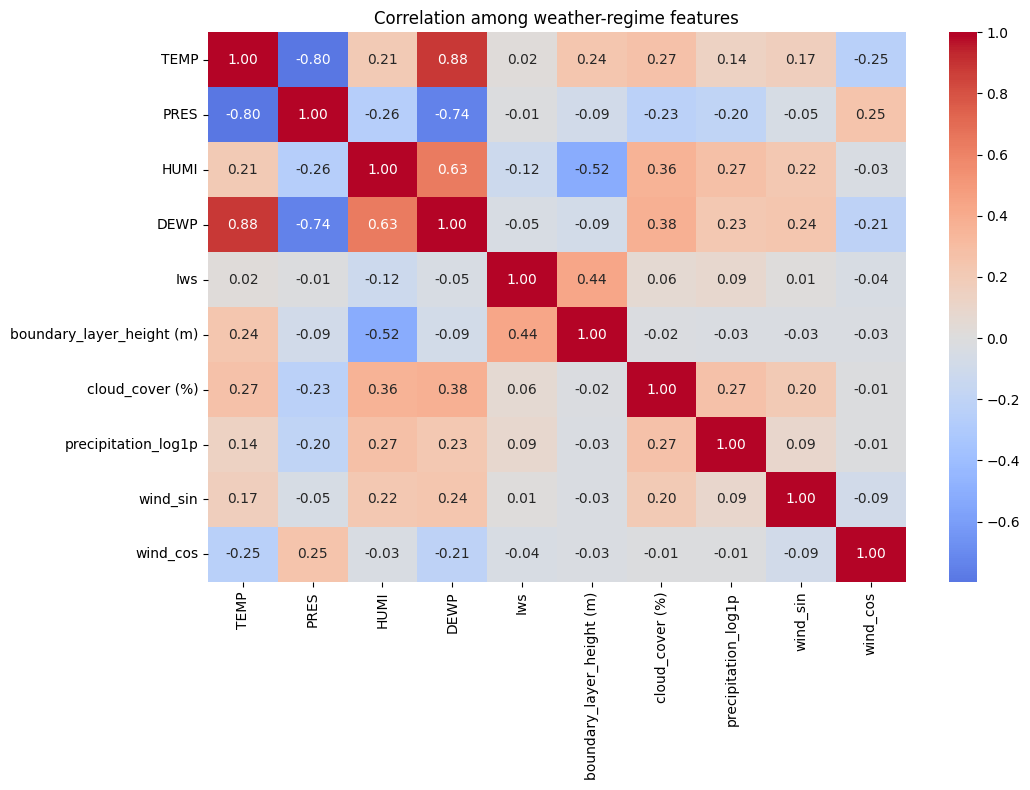

In [13]:
# =============================================================================
# Correlation diagnostics for weather-regime features
# =============================================================================

corr_matrix = df_clean[CLUSTER_WEATHER_FEATURES].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation among weather-regime features")
plt.tight_layout()
plt.show()

In [14]:
# =============================================================================
# StandardScaler and PCA without 2015 leakage
# =============================================================================

cluster_train_mask = df_clean["year"] <= 2014

cluster_scaler = StandardScaler()
cluster_scaler.fit(df_clean.loc[cluster_train_mask, CLUSTER_WEATHER_FEATURES])

weather_scaled_train = cluster_scaler.transform(
    df_clean.loc[cluster_train_mask, CLUSTER_WEATHER_FEATURES]
)

weather_scaled_all = cluster_scaler.transform(
    df_clean[CLUSTER_WEATHER_FEATURES]
)

pca = PCA(n_components=3, random_state=RANDOM_STATE)
pca.fit(weather_scaled_train)

weather_pca_train = pca.transform(weather_scaled_train)
weather_pca_all = pca.transform(weather_scaled_all)

explained = pca.explained_variance_ratio_

print("── PCA EXPLAINED VARIANCE ─────────────────────────────────────────")
for i, value in enumerate(explained, start=1):
    print(f"PC{i}: {value * 100:.1f}%")

print(f"Cumulative PC1–PC3: {explained.sum() * 100:.1f}%")

── PCA EXPLAINED VARIANCE ─────────────────────────────────────────
PC1: 33.1%
PC2: 17.6%
PC3: 12.3%
Cumulative PC1–PC3: 63.0%


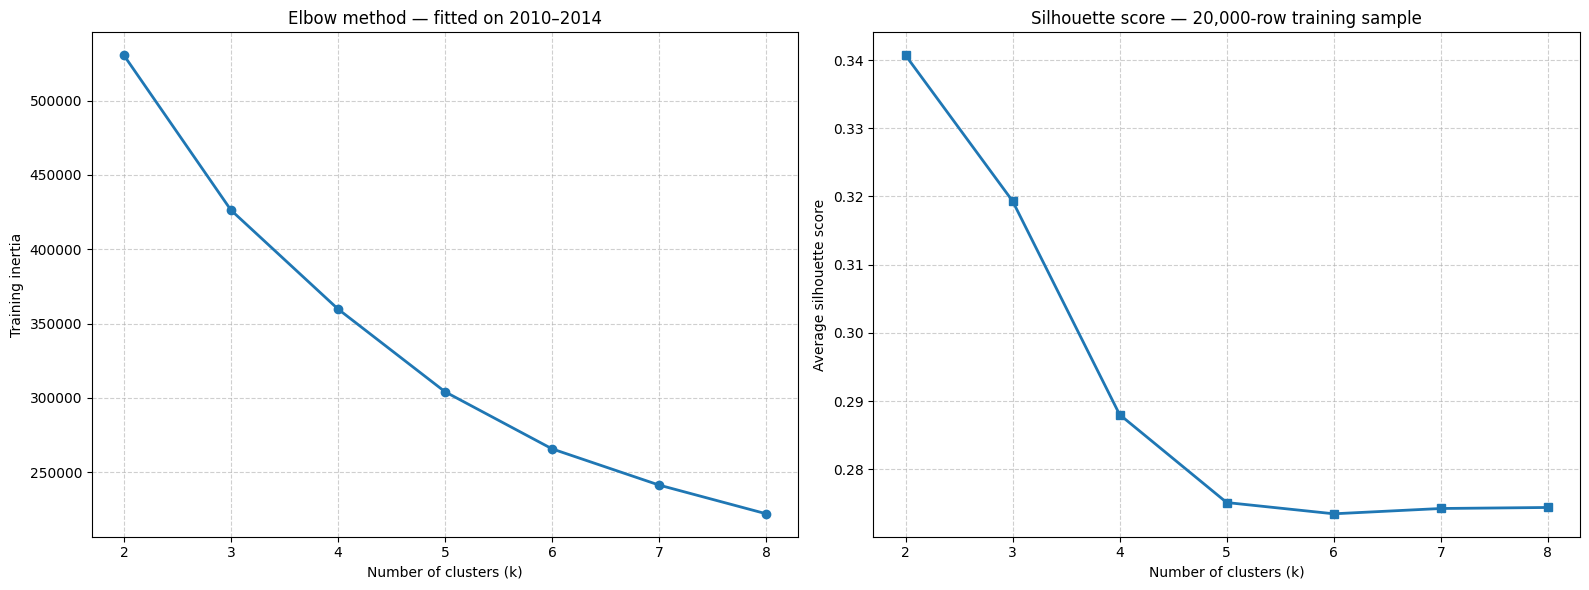

,k,training_inertia,sample_silhouette
0,2,530512.9017,0.3407
1,3,426341.1447,0.3193
2,4,359795.0997,0.2880
3,5,304120.7960,0.2751
4,6,265718.3309,0.2735
5,7,241357.1490,0.2742
6,8,222055.3608,0.2744


In [15]:

# =============================================================================
# Select k on the training period only
# =============================================================================
# K-Means is fitted on 2010–2014. Silhouette is evaluated on a reproducible
# training sample to avoid excessive memory use while preserving comparability.
k_range = range(2, 9)
inertia_values = []
silhouette_scores = []

rng = np.random.default_rng(RANDOM_STATE)
sample_size = min(20_000, len(weather_pca_train))
sample_idx = rng.choice(len(weather_pca_train), size=sample_size, replace=False)
silhouette_sample = weather_pca_train[sample_idx]

for k in k_range:
    candidate = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20,
    )
    candidate.fit(weather_pca_train)
    inertia_values.append(candidate.inertia_)
    sample_labels = candidate.predict(silhouette_sample)
    silhouette_scores.append(
        silhouette_score(silhouette_sample, sample_labels)
    )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.plot(k_range, inertia_values, marker="o", linewidth=2)
ax1.set_title("Elbow method — fitted on 2010–2014")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Training inertia")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.set_xticks(list(k_range))

ax2.plot(k_range, silhouette_scores, marker="s", linewidth=2)
ax2.set_title(f"Silhouette score — {sample_size:,}-row training sample")
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Average silhouette score")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.set_xticks(list(k_range))

plt.tight_layout()
plt.show()

selection_table = pd.DataFrame({
    "k": list(k_range),
    "training_inertia": inertia_values,
    "sample_silhouette": silhouette_scores,
})
display(selection_table.round(4))

In [16]:

# =============================================================================
# Final K-Means weather regimes
# =============================================================================
# k=4 is retained for consistency with the analytical design and interpretability.
# The model is fitted on 2010–2014 and used to assign regimes to the full panel.
N_CLUSTERS = 4
kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=20,
)
kmeans.fit(weather_pca_train)
clusters = kmeans.predict(weather_pca_all)

df_clean["Cluster"] = clusters
print(df_clean["Cluster"].value_counts().sort_index())
print("✓ K-Means fitted on 2010–2014 and applied to all years.")

Cluster
0    53075
1    69236
2    28239
3    25443
Name: count, dtype: int64
✓ K-Means fitted on 2010–2014 and applied to all years.


In [17]:
# =============================================================================
# PCA loadings
# =============================================================================

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2", "PC3"],
    index=CLUSTER_WEATHER_FEATURES,
)

print("Unique wind sine values:", df_clean["wind_sin"].nunique())
print("Unique wind cosine values:", df_clean["wind_cos"].nunique())

display(loadings.round(3))

Unique wind sine values: 318
Unique wind cosine values: 318


,PC1,PC2,PC3
TEMP,0.466,0.269,-0.221
PRES,-0.448,-0.185,0.243
HUMI,0.345,-0.444,0.150
DEWP,0.525,-0.008,-0.111
Iws,-0.007,0.453,0.468
boundary_layer_height (m),-0.042,0.672,0.137
cloud_cover (%),0.289,-0.078,0.439
precipitation_log1p,0.202,-0.065,0.503
wind_sin,0.182,-0.059,0.276
wind_cos,-0.168,-0.162,0.312


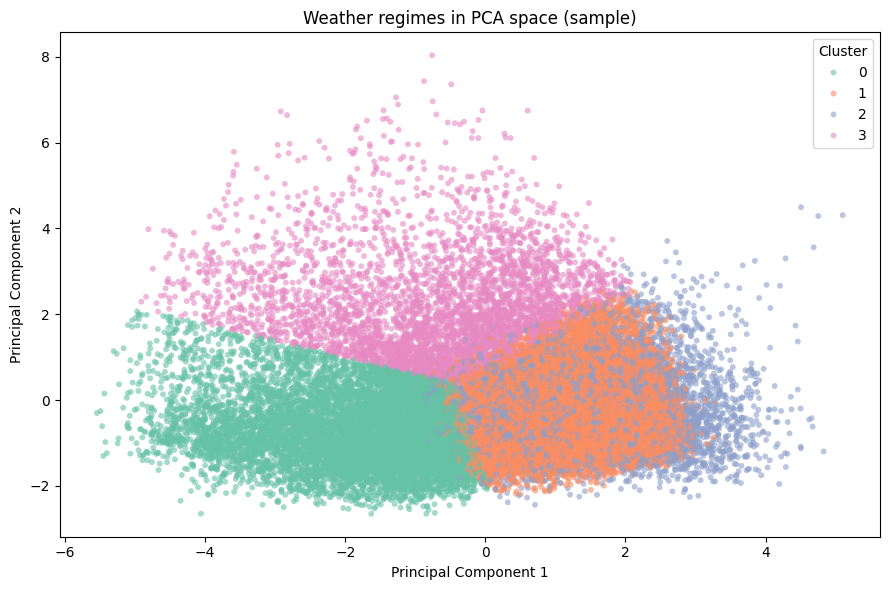

In [18]:
# =============================================================================
# PCA cluster visualization
# =============================================================================
# Plot a reproducible sample to keep the figure readable.
plot_n = min(30_000, len(df_clean))
plot_idx = np.random.default_rng(RANDOM_STATE).choice(
    len(df_clean), size=plot_n, replace=False
)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=weather_pca_all[plot_idx, 0],
    y=weather_pca_all[plot_idx, 1],
    hue=clusters[plot_idx],
    palette="Set2",
    s=18,
    alpha=0.6,
    linewidth=0,
)
plt.title("Weather regimes in PCA space (sample)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

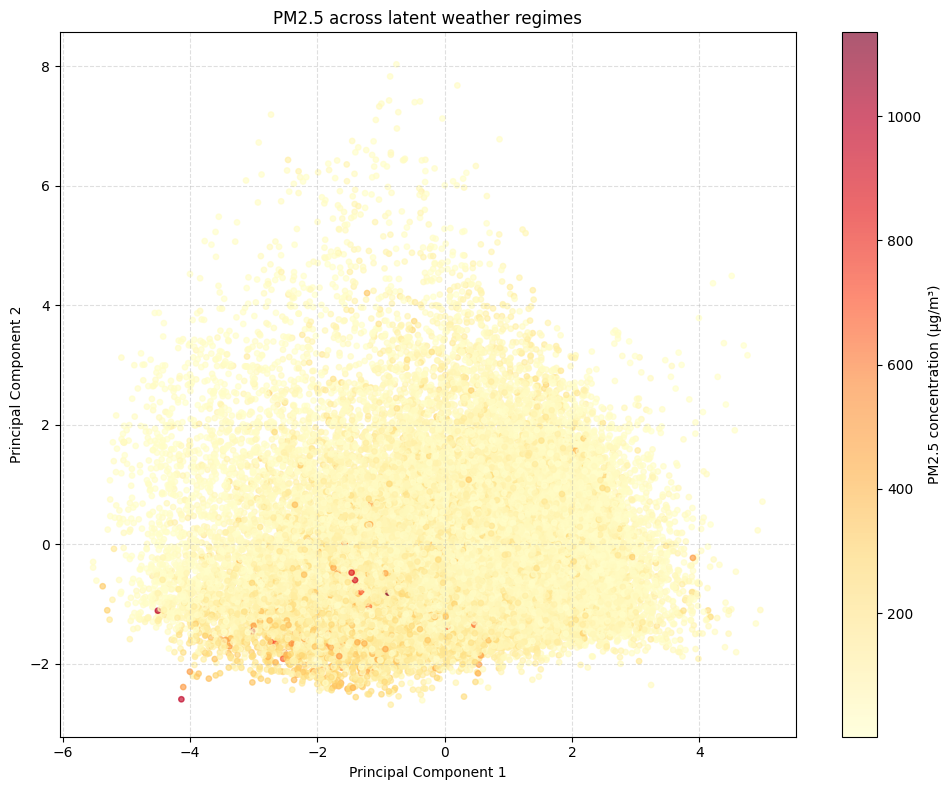

In [19]:

# =============================================================================
# PM2.5 burden across latent weather space
# =============================================================================
plot_df = pd.DataFrame({
    "PC1": weather_pca_all[:, 0],
    "PC2": weather_pca_all[:, 1],
    "PM25": df_clean["PM"].to_numpy(),
})

plot_n = min(30_000, len(plot_df))
plot_df = plot_df.sample(plot_n, random_state=RANDOM_STATE)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c=plot_df["PM25"],
    cmap="YlOrRd",
    s=15,
    alpha=0.65,
)
cbar = plt.colorbar(scatter)
cbar.set_label("PM2.5 concentration (µg/m³)")
plt.title("PM2.5 across latent weather regimes")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [20]:

# =============================================================================
# Physical and pollution profile of each cluster
# =============================================================================
current_weather_columns = [
    "TEMP", "PRES", "HUMI", "DEWP", "Iws",
    "wind_direction_10m (°)",
    "boundary_layer_height (m)",
    "cloud_cover (%)",
    "precipitation",
    "PM",
]
analysis_df = df_clean[current_weather_columns + ["Cluster"]].copy()
cluster_profile = analysis_df.groupby("Cluster", observed=True).mean()

print("── ACTUAL PROFILE MEANS PER CLUSTER ──────────────────────────────────")
display(cluster_profile.round(2))

── ACTUAL PROFILE MEANS PER CLUSTER ──────────────────────────────────


,TEMP,PRES,HUMI,DEWP,Iws,wind_direction_10m (°),boundary_layer_height (m),cloud_cover (%),precipitation,PM
Cluster,,,,,,,,,,
0,2.91,1024.66,58.92,-5.21,8.00,204.71,270.70,35.81,0.00,101.07
1,22.72,1009.14,75.95,17.87,7.24,174.15,337.45,60.76,0.02,70.39
2,19.48,1011.91,83.82,16.55,13.34,115.05,506.70,94.94,0.68,46.40
3,18.61,1014.64,38.45,2.81,14.92,194.50,1415.05,40.81,0.00,55.33


── ABSOLUTE HOURS PER CITY AND CLUSTER (SORTED) ──────────────────
Cluster        0      1      2      3
city                                 
Beijing    22687  16103   1954  10097
Shenyang   10677   7171   1947   6290
Shanghai    8042  11494  10918   4469
Chengdu     8242  16112   4174   2110
Guangzhou   3427  18356   9246   2477

── PERCENTAGE DISTRIBUTION PER CITY (ROW TOTAL = 100%) ──────────────
Cluster       0     1     2     3
city                             
Beijing    44.6  31.7   3.8  19.9
Shenyang   40.9  27.5   7.5  24.1
Shanghai   23.0  32.9  31.3  12.8
Chengdu    26.9  52.6  13.6   6.9
Guangzhou  10.2  54.8  27.6   7.4


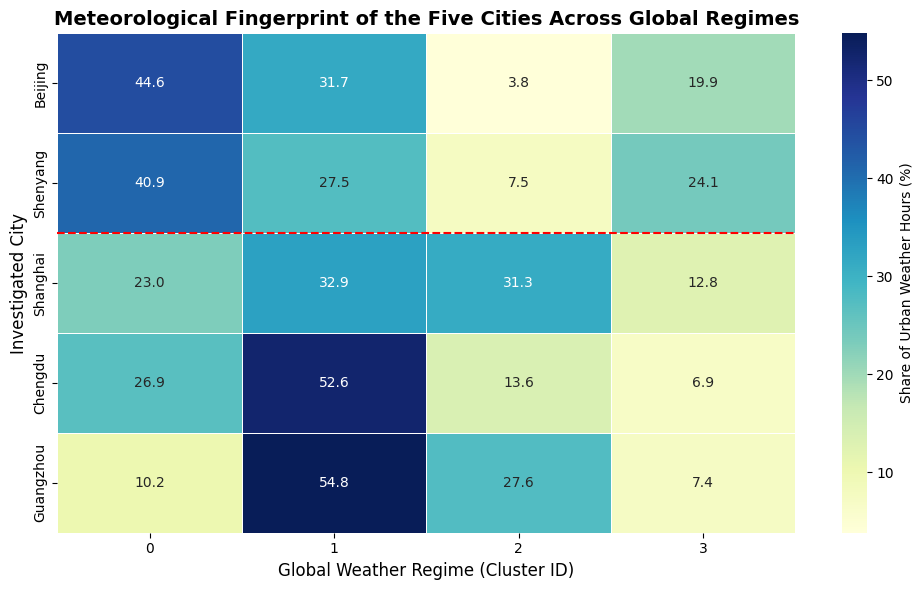

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate absolute frequencies (hours per city and cluster)
crosstab_abs = pd.crosstab(df_clean["city"], df_clean["Cluster"])

# 2. Convert to percentages per city (row sum = 100%)
crosstab_pct = (
    pd.crosstab(df_clean["city"], df_clean["Cluster"], normalize="index") * 100
)

# ── NEW: Define explicit order (Northern cities first, then Southern cities) ──
desired_order = ["Beijing", "Shenyang", "Shanghai", "Chengdu", "Guangzhou"]
crosstab_pct = crosstab_pct.reindex(desired_order)
crosstab_abs = crosstab_abs.reindex(desired_order)

print(
    "── ABSOLUTE HOURS PER CITY AND CLUSTER (SORTED) ──────────────────"
)
print(crosstab_abs)
print(
    "\n── PERCENTAGE DISTRIBUTION PER CITY (ROW TOTAL = 100%) ──────────────"
)
print(crosstab_pct.round(1))

# 3. Draw scientific heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    crosstab_pct,
    annot=True,  # Display numbers inside the cells
    fmt=".1f",  # One decimal place
    cmap="YlGnBu",  # Scientific color palette
    cbar_kws={"label": "Share of Urban Weather Hours (%)"},
    linewidths=0.5,
)

# Visual separator in the plot: a horizontal line between Northern and Southern cities
# Since Beijing and Shenyang are the first two rows (index 0 and 1), we draw the line at y=2
plt.axhline(
    y=2,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="North/South Boundary (Heating Zone)",
)

plt.title(
    "Meteorological Fingerprint of the Five Cities Across Global Regimes",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Global Weather Regime (Cluster ID)", fontsize=12)
plt.ylabel("Investigated City", fontsize=12)
plt.tight_layout()
plt.show()

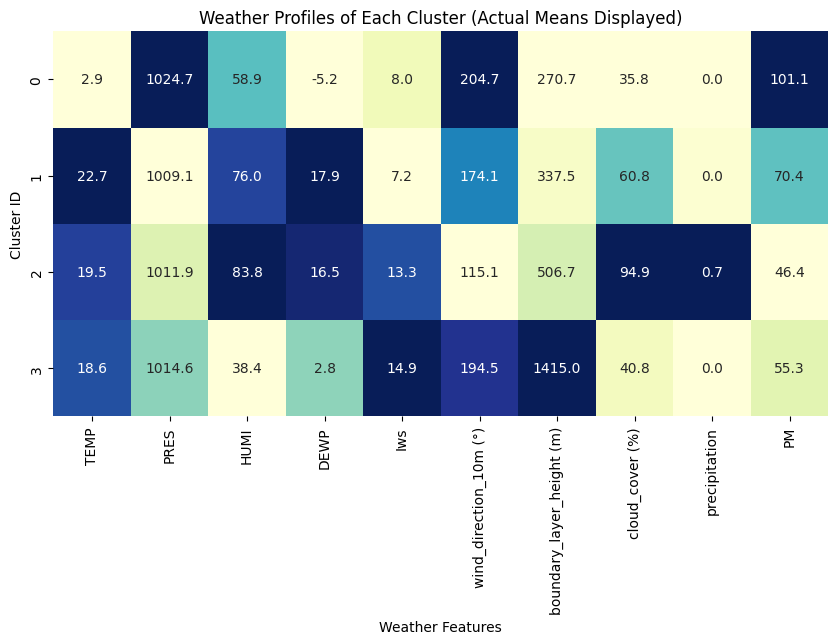

In [22]:
# Normalize the mean values to a scale from 0 to 1,
# allowing a fair comparison of temperature and air pressure in the same heatmap.
plot_scaler = MinMaxScaler()
cluster_profile_scaled = pd.DataFrame(
    plot_scaler.fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index,
)

# Draw heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(
    cluster_profile_scaled,
    annot=cluster_profile,
    fmt=".1f",
    cmap="YlGnBu",
    cbar=False,
)
plt.title("Weather Profiles of Each Cluster (Actual Means Displayed)")
plt.ylabel("Cluster ID")
plt.xlabel("Weather Features")
plt.show()

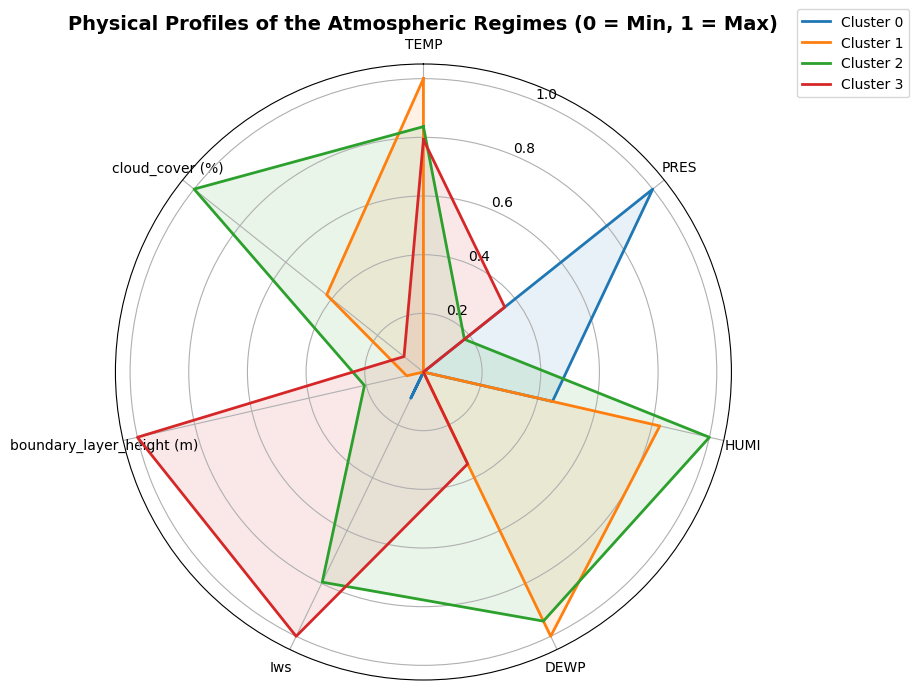

In [23]:
# 1. Calculate the mean values of the actual features per cluster
# (Ensure that 'clusters' contains the IDs from 0 to 3 for k=4)
df_clean["Cluster"] = clusters
features_to_plot = ["TEMP", "PRES", "HUMI", "DEWP", "Iws", "boundary_layer_height (m)", "cloud_cover (%)"]
cluster_means = df_clean.groupby("Cluster")[features_to_plot].mean()

# 2. Scale data to 0-1 to make them comparable in the radar chart
scaler = MinMaxScaler()
cluster_means_scaled = scaler.fit_transform(cluster_means)

# 3. Draw Radar Chart
labels = features_to_plot
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close the circle

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i in range(len(cluster_means)):
    values = cluster_means_scaled[i].tolist()
    values += values[:1]  # Close the circle
    ax.plot(angles, values, linewidth=2, label=f"Cluster {i}")
    ax.fill(angles, values, alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title(
    "Physical Profiles of the Atmospheric Regimes (0 = Min, 1 = Max)",
    fontsize=14,
    fontweight="bold",
)
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()

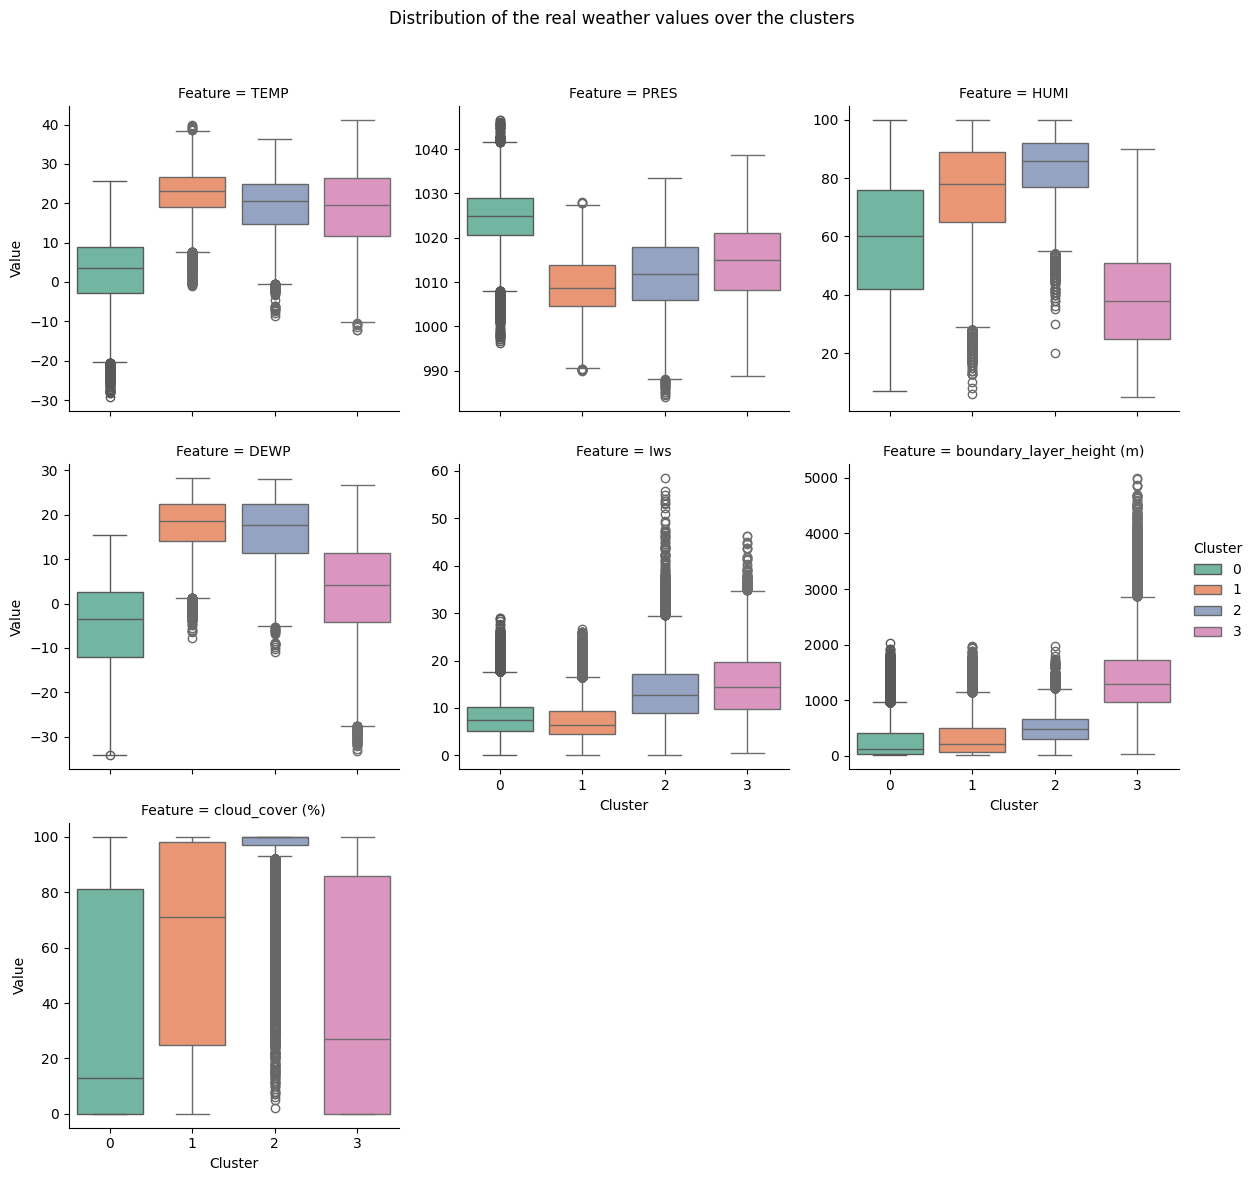

In [24]:
import seaborn as sns

# Melts the DataFrame for Seaborn FacetGrid
df_melt = df_clean.melt(id_vars=['Cluster'], value_vars=features_to_plot, 
                        var_name='Feature', value_name='Value')

g = sns.FacetGrid(df_melt, col="Feature", hue="Cluster", col_wrap=3, sharey=False, height=4, palette='Set2')
g.map(sns.boxplot, "Cluster", "Value", order=list(range(N_CLUSTERS)))
g.add_legend()
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Distribution of the real weather values over the clusters')
plt.show()

In [25]:
# 1. Filter the columns for the smog analysis (pure original values)
# Replace 'PM' with your exact column name (e.g., 'PM_Dongsi' or 'PM')
pm_feature = "PM"

# 2. Calculate the most critical economic metrics per cluster
pm_analysis = (
    df_clean.groupby("Cluster")[pm_feature]
    .agg(
        hourly_observations="count",
        average_pm25="mean",
        median_pm25="median",
        maximum_pm25="max",
    )
    .round(2)
)

print("── PM2.5 POLLUTION BURDEN PER ATMOSPHERIC REGIME ──────────────────────────")
print(pm_analysis)

── PM2.5 POLLUTION BURDEN PER ATMOSPHERIC REGIME ──────────────────────────
         hourly_observations  average_pm25  median_pm25  maximum_pm25
Cluster                                                              
0                      53075        101.07        75.75       1134.67
1                      69236         70.39        54.67        700.00
2                      28239         46.40        35.33       1129.67
3                      25443         55.33        41.00        761.00


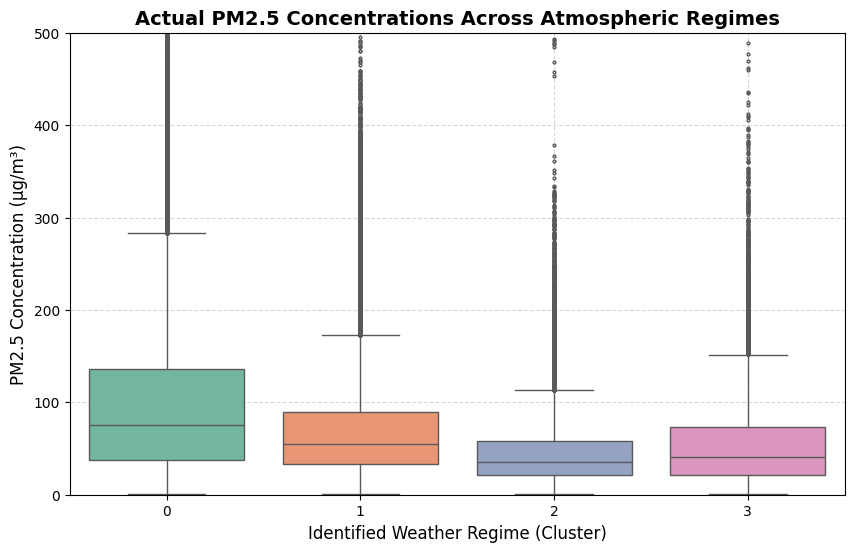

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Box plot of the unscaled PM2.5 values per cluster
sns.boxplot(
    data=df_clean,
    x="Cluster",
    y=pm_feature,
    palette="Set2",
    fliersize=2,  # Makes the outlier points smaller and more legible
)

# Economically sensible limitation of the Y-axis (e.g., up to 500 μg/m³) to keep the box readable
plt.ylim(0, 500)

plt.title(
    "Actual PM2.5 Concentrations Across Atmospheric Regimes",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Identified Weather Regime (Cluster)", fontsize=12)
plt.ylabel("PM2.5 Concentration (µg/m³)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

In [27]:
# Fit full PCA to show total variance across all selected weather variables
# This is necessary to calculate the maximum total variance
pca_full = PCA(n_components=len(CLUSTER_WEATHER_FEATURES))
pca_full.fit(weather_scaled_train)

# Display results clearly
print("── EXPLAINED VARIANCE PER PRINCIPAL COMPONENT (PCA) ──────────────────────────")
for i, var in enumerate(pca_full.explained_variance_ratio_):
    print(f"Principal Component {i+1} (PC{i+1}) explains: {var*100:.1f}% of the variance")

print("\n── CUMULATIVE INFORMATION COVERAGE ────────────────────")
cum_var_2 = np.sum(pca_full.explained_variance_ratio_[:2]) * 100
cum_var_3 = np.sum(pca_full.explained_variance_ratio_[:3]) * 100
cum_var_4 = np.sum(pca_full.explained_variance_ratio_[:4]) * 100

print(f"➡ With n=2 components (PC1 + PC2), you cover {cum_var_2:.1f}% of the weather information.")
print(f"➡ With n=3 components (PC1 + PC2 + PC3), you cover {cum_var_3:.1f}% of the weather information.")
print(f"➡ With n=4 components (PC1 + PC2 + PC3 + PC4), you cover {cum_var_4:.1f}% of the weather information.")

── EXPLAINED VARIANCE PER PRINCIPAL COMPONENT (PCA) ──────────────────────────
Principal Component 1 (PC1) explains: 33.1% of the variance
Principal Component 2 (PC2) explains: 17.6% of the variance
Principal Component 3 (PC3) explains: 12.3% of the variance
Principal Component 4 (PC4) explains: 9.8% of the variance
Principal Component 5 (PC5) explains: 8.5% of the variance
Principal Component 6 (PC6) explains: 7.1% of the variance
Principal Component 7 (PC7) explains: 6.6% of the variance
Principal Component 8 (PC8) explains: 3.0% of the variance
Principal Component 9 (PC9) explains: 1.9% of the variance
Principal Component 10 (PC10) explains: 0.1% of the variance

── CUMULATIVE INFORMATION COVERAGE ────────────────────
➡ With n=2 components (PC1 + PC2), you cover 50.8% of the weather information.
➡ With n=3 components (PC1 + PC2 + PC3), you cover 63.0% of the weather information.
➡ With n=4 components (PC1 + PC2 + PC3 + PC4), you cover 72.8% of the weather information.


In [28]:

# =============================================================================
# Stratified descriptive validation of PM2.5 separation by cluster
# =============================================================================

from itertools import combinations
import scipy.stats as stats
import pandas as pd
import numpy as np

def pairwise_mannwhitney_bonferroni(data, value_col="PM", group_col="Cluster"):
    groups = sorted(data[group_col].dropna().unique())
    pairs = list(combinations(groups, 2))
    n_tests = max(len(pairs), 1)

    rows = []
    for group_a, group_b in pairs:
        a = data.loc[data[group_col].eq(group_a), value_col].dropna()
        b = data.loc[data[group_col].eq(group_b), value_col].dropna()
        if len(a) < 2 or len(b) < 2:
            continue
        u_stat, raw_p = stats.mannwhitneyu(a, b, alternative="two-sided")
        bonf_p = min(raw_p * n_tests, 1.0)
        rows.append({
            "cluster_a": group_a,
            "cluster_b": group_b,
            "n_a": len(a),
            "n_b": len(b),
            "median_a": a.median(),
            "median_b": b.median(),
            "median_difference": a.median() - b.median(),
            "u_statistic": u_stat,
            "bonferroni_p_value": bonf_p,
            "significant_5pct": bonf_p < 0.05,
        })
    return pd.DataFrame(rows)

regime_scenarios = [
    (0, "Outside Defined Northern Heating Regime"),
    (1, "Inside Defined Northern Heating Regime"),
]

required_cols = {"heating_regime", "Cluster", "PM"}
missing_cols = required_cols.difference(df_clean.columns)
if missing_cols:
    raise KeyError(f"Missing required columns: {sorted(missing_cols)}")

for regime_status, regime_name in regime_scenarios:
    print("\n" + "=" * 80)
    print(f"STRATIFIED CLUSTER VALIDATION: {regime_name}")
    print("=" * 80)

    df_sub = (
        df_clean.loc[
            df_clean["heating_regime"].eq(regime_status),
            ["city", "year", "month", "day", "Cluster", "PM"],
        ]
        .dropna(subset=["Cluster", "PM"])
        .copy()
    )

    if df_sub.empty:
        print("No observations available for this regime.")
        continue

    cluster_counts = df_sub["Cluster"].value_counts().sort_index()
    valid_clusters = cluster_counts[cluster_counts >= 2].index.tolist()

    if len(valid_clusters) < 2:
        print("Fewer than two sufficiently populated clusters; test skipped.")
        continue

    df_test = df_sub[df_sub["Cluster"].isin(valid_clusters)].copy()
    cluster_groups = [
        df_test.loc[df_test["Cluster"].eq(cluster), "PM"].to_numpy()
        for cluster in valid_clusters
    ]

    kw_stat, kw_p = stats.kruskal(*cluster_groups)
    n_obs = len(df_test)
    n_groups = len(valid_clusters)
    epsilon_sq = max(0, (kw_stat - n_groups + 1) / (n_obs - n_groups))

    print(f"Observations: {n_obs:,}")
    print(f"Clusters tested: {valid_clusters}")
    print(f"Kruskal–Wallis H-statistic: {kw_stat:,.2f}")
    print(f"Asymptotic p-value: {kw_p:.4e}")
    print(f"Kruskal–Wallis epsilon-squared: {epsilon_sq:.4f}")

    target_table = (
        df_test.groupby("Cluster", observed=True)["PM"]
        .agg(
            hourly_observations="count",
            mean_pm25="mean",
            median_pm25="median",
            std_deviation="std",
            maximum_pm25="max",
        )
        .round(1)
    )

    print("\nPM₂.₅ target distribution by weather cluster:")
    display(target_table)

    if kw_p < 0.05:
        print("\nPairwise Mann–Whitney tests with Bonferroni correction:")
        pairwise_results = pairwise_mannwhitney_bonferroni(
            df_test, value_col="PM", group_col="Cluster"
        )
        display(pairwise_results.round(4))

    print(
        "\nInterpretation caution: this is a descriptive stratified analysis. "
        "Hourly observations are temporally autocorrelated, and the heating "
        "indicator is also associated with city and season. Conventional p-values "
        "therefore do not establish a causal heating-policy effect."
    )


STRATIFIED CLUSTER VALIDATION: Outside Defined Northern Heating Regime
Observations: 150,258
Clusters tested: [0, 1, 2, 3]
Kruskal–Wallis H-statistic: 11,654.57
Asymptotic p-value: 0.0000e+00
Kruskal–Wallis epsilon-squared: 0.0775

PM₂.₅ target distribution by weather cluster:


,hourly_observations,mean_pm25,median_pm25,std_deviation,maximum_pm25
Cluster,,,,,
0,31005,88.4,71.0,69.9,1134.7
1,69082,70.1,54.7,56.1,700.0
2,27947,45.9,35.0,39.7,1129.7
3,22224,56.0,42.5,48.3,761.0



Pairwise Mann–Whitney tests with Bonferroni correction:


,cluster_a,cluster_b,n_a,n_b,median_a,median_b,median_difference,u_statistic,bonferroni_p_value,significant_5pct
0,0,1,31005,69082,71.0000,54.6667,16.3333,1.253142e+09,0.0,True
1,0,2,31005,27947,71.0000,35.0000,36.0000,6.306290e+08,0.0,True
2,0,3,31005,22224,71.0000,42.5000,28.5000,4.595387e+08,0.0,True
3,1,2,69082,27947,54.6667,35.0000,19.6667,1.278068e+09,0.0,True
4,1,3,69082,22224,54.6667,42.5000,12.1667,9.127858e+08,0.0,True
5,2,3,27947,22224,35.0000,42.5000,-7.5000,2.743239e+08,0.0,True



Interpretation caution: this is a descriptive stratified analysis. Hourly observations are temporally autocorrelated, and the heating indicator is also associated with city and season. Conventional p-values therefore do not establish a causal heating-policy effect.

STRATIFIED CLUSTER VALIDATION: Inside Defined Northern Heating Regime
Observations: 25,735
Clusters tested: [0, 1, 2, 3]
Kruskal–Wallis H-statistic: 1,942.29
Asymptotic p-value: 0.0000e+00
Kruskal–Wallis epsilon-squared: 0.0754

PM₂.₅ target distribution by weather cluster:


,hourly_observations,mean_pm25,median_pm25,std_deviation,maximum_pm25
Cluster,,,,,
0,22070,118.8,86.0,110.1,1065.5
1,154,223.0,209.1,99.1,542.0
2,292,93.8,82.0,66.6,502.3
3,3219,51.0,25.3,60.8,526.0



Pairwise Mann–Whitney tests with Bonferroni correction:


,cluster_a,cluster_b,n_a,n_b,median_a,median_b,median_difference,u_statistic,bonferroni_p_value,significant_5pct
0,0,1,22070,154,86.000,209.1250,-123.1250,700056.5,0.0,True
1,0,2,22070,292,86.000,82.0000,4.0000,3338671.0,1.0,False
2,0,3,22070,3219,86.000,25.3333,60.6667,51728369.5,0.0,True
3,1,2,154,292,209.125,82.0000,127.1250,40127.0,0.0,True
4,1,3,154,3219,209.125,25.3333,183.7917,470326.5,0.0,True
5,2,3,292,3219,82.000,25.3333,56.6667,730327.5,0.0,True



Interpretation caution: this is a descriptive stratified analysis. Hourly observations are temporally autocorrelated, and the heating indicator is also associated with city and season. Conventional p-values therefore do not establish a causal heating-policy effect.


In [29]:

# =============================================================================
# Cross-city PM2.5 disparity in corrected heating window
# =============================================================================
# Uses the precise Nov15–Mar15 heating-policy calendar window for all cities.
# This is descriptive panel evidence, not a causal estimate.

from itertools import combinations
import scipy.stats as stats
import pandas as pd

def pairwise_city_mannwhitney_bonferroni(data, value_col="PM", group_col="city", order=None):
    groups = order if order is not None else sorted(data[group_col].dropna().unique())
    groups = [g for g in groups if g in set(data[group_col].dropna().unique())]
    pairs = list(combinations(groups, 2))
    n_tests = max(len(pairs), 1)
    rows = []
    for a_city, b_city in pairs:
        a = data.loc[data[group_col].eq(a_city), value_col].dropna()
        b = data.loc[data[group_col].eq(b_city), value_col].dropna()
        if len(a) < 2 or len(b) < 2:
            continue
        u_stat, raw_p = stats.mannwhitneyu(a, b, alternative="two-sided")
        rows.append({
            "city_a": a_city,
            "city_b": b_city,
            "n_a": len(a),
            "n_b": len(b),
            "median_a": a.median(),
            "median_b": b.median(),
            "median_difference": a.median() - b.median(),
            "bonferroni_p_value": min(raw_p * n_tests, 1.0),
        })
    return pd.DataFrame(rows)

desired_order = ["Beijing", "Shenyang", "Shanghai", "Chengdu", "Guangzhou"]

panel_scenarios = [
    ("Outside Nov15–Mar15 Heating Window", df_clean[df_clean["heating_period"].eq(0)]),
    ("Inside Nov15–Mar15 Heating Window", df_clean[df_clean["heating_period"].eq(1)]),
]

for scenario_name, df_sub_city in panel_scenarios:
    print("\n" + "=" * 80)
    print(f"PANEL DISPARITY CHECK: {scenario_name}")
    print("=" * 80)

    if len(df_sub_city) == 0:
        print("No data found for this timeframe split. Skipping.")
        continue

    city_groups = [
        df_sub_city.loc[df_sub_city["city"].eq(city), "PM"].dropna().to_numpy()
        for city in desired_order
        if df_sub_city["city"].eq(city).sum() >= 2
    ]

    if len(city_groups) < 2:
        print("Fewer than two cities with enough observations. Skipping.")
        continue

    kw_stat, kw_p = stats.kruskal(*city_groups)
    print(f"Global Kruskal–Wallis H-statistic: {kw_stat:.2f}")
    print(f"Global p-value:                    {kw_p:.4e}")

    city_table = (
        df_sub_city.groupby("city", observed=True)["PM"]
        .agg(
            hourly_observations="count",
            mean_pm25="mean",
            median_pm25="median",
            std_deviation="std",
        )
        .round(1)
        .reindex(desired_order)
    )

    print(f"\nPM2.5 disparity matrix ({scenario_name}):")
    display(city_table)

    if kw_p < 0.05:
        print("\nPairwise city tests with Bonferroni correction:")
        city_pairwise = pairwise_city_mannwhitney_bonferroni(
            df_sub_city, value_col="PM", group_col="city", order=desired_order
        )
        display(city_pairwise.round(4))

    print(
        "\nCaution: this compares city distributions inside/outside a calendar window. "
        "It does not isolate a causal heating-policy effect."
    )


PANEL DISPARITY CHECK: Outside Nov15–Mar15 Heating Window
Global Kruskal–Wallis H-statistic: 8673.60
Global p-value:                    0.0000e+00

PM2.5 disparity matrix (Outside Nov15–Mar15 Heating Window):


,hourly_observations,mean_pm25,median_pm25,std_deviation
city,,,,
Beijing,33784,87.2,68.2,74.0
Shenyang,17407,62.6,47.3,61.2
Shanghai,23208,45.4,37.7,32.5
Chengdu,20847,63.0,53.3,40.2
Guangzhou,22795,45.1,37.0,33.5



Pairwise city tests with Bonferroni correction:


,city_a,city_b,n_a,n_b,median_a,median_b,median_difference,bonferroni_p_value
0,Beijing,Shenyang,33784,17407,68.2500,47.3333,20.9167,0.0000
1,Beijing,Shanghai,33784,23208,68.2500,37.6667,30.5833,0.0000
2,Beijing,Chengdu,33784,20847,68.2500,53.3333,14.9167,0.0000
3,Beijing,Guangzhou,33784,22795,68.2500,37.0000,31.2500,0.0000
4,Shenyang,Shanghai,17407,23208,47.3333,37.6667,9.6667,0.0000
5,Shenyang,Chengdu,17407,20847,47.3333,53.3333,-6.0000,0.0000
6,Shenyang,Guangzhou,17407,22795,47.3333,37.0000,10.3333,0.0000
7,Shanghai,Chengdu,23208,20847,37.6667,53.3333,-15.6667,0.0000
8,Shanghai,Guangzhou,23208,22795,37.6667,37.0000,0.6667,0.6792
9,Chengdu,Guangzhou,20847,22795,53.3333,37.0000,16.3333,0.0000



Caution: this compares city distributions inside/outside a calendar window. It does not isolate a causal heating-policy effect.

PANEL DISPARITY CHECK: Inside Nov15–Mar15 Heating Window
Global Kruskal–Wallis H-statistic: 3668.83
Global p-value:                    0.0000e+00

PM2.5 disparity matrix (Inside Nov15–Mar15 Heating Window):


,hourly_observations,mean_pm25,median_pm25,std_deviation
city,,,,
Beijing,17057,111.0,72.0,114.8
Shenyang,8678,110.0,84.0,91.2
Shanghai,11715,73.3,57.0,57.6
Chengdu,9791,116.0,99.0,69.7
Guangzhou,10711,63.8,59.0,36.0



Pairwise city tests with Bonferroni correction:


,city_a,city_b,n_a,n_b,median_a,median_b,median_difference,bonferroni_p_value
0,Beijing,Shenyang,17057,8678,72.0,84.0,-12.0,0.0000
1,Beijing,Shanghai,17057,11715,72.0,57.0,15.0,0.0000
2,Beijing,Chengdu,17057,9791,72.0,99.0,-27.0,0.0000
3,Beijing,Guangzhou,17057,10711,72.0,59.0,13.0,0.0000
4,Shenyang,Shanghai,8678,11715,84.0,57.0,27.0,0.0000
5,Shenyang,Chengdu,8678,9791,84.0,99.0,-15.0,0.0000
6,Shenyang,Guangzhou,8678,10711,84.0,59.0,25.0,0.0000
7,Shanghai,Chengdu,11715,9791,57.0,99.0,-42.0,0.0000
8,Shanghai,Guangzhou,11715,10711,57.0,59.0,-2.0,0.1064
9,Chengdu,Guangzhou,9791,10711,99.0,59.0,40.0,0.0000



Caution: this compares city distributions inside/outside a calendar window. It does not isolate a causal heating-policy effect.


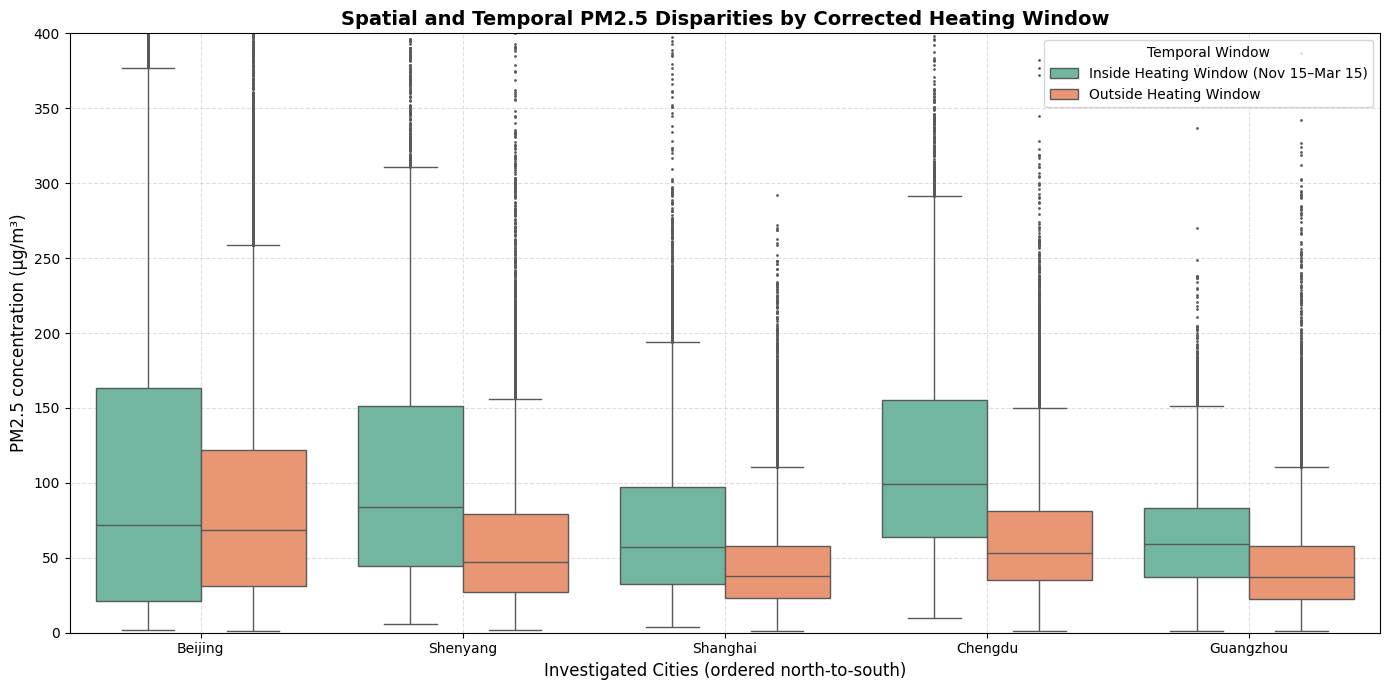

In [30]:

# =============================================================================
# Cross-city PM2.5 distributions inside/outside heating window
# =============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df_plot = df_clean.copy()
df_plot["Timeframe"] = df_plot["heating_period"].map({
    1: "Inside Heating Window (Nov 15–Mar 15)",
    0: "Outside Heating Window",
})

desired_order = ["Beijing", "Shenyang", "Shanghai", "Chengdu", "Guangzhou"]

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df_plot,
    x="city",
    y="PM",
    hue="Timeframe",
    order=desired_order,
    palette="Set2",
    fliersize=1,
)
plt.ylim(0, 400)
plt.title(
    "Spatial and Temporal PM2.5 Disparities by Corrected Heating Window",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Investigated Cities (ordered north-to-south)", fontsize=12)
plt.ylabel("PM2.5 concentration (µg/m³)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Temporal Window", loc="upper right")
plt.tight_layout()
plt.show()

## 8. Discussion & Conclusion *(complete for final submission)*

The three method blocks provide complementary findings. The causal-inference block shows that the corrected northern heating-regime period is positively associated with PM2.5 after adjusting for observed weather variables and fixed effects. The supervised-learning block shows that Random Forest delta improves prediction compared with lag-1 persistence and OLS, although the pre-specified 15% improvement threshold is not reached. The unsupervised-learning block shows that cold and stagnant weather regimes are associated with the highest PM2.5 concentrations.

The main limitations are that the analysis is conducted at the city-hour level, EDGAR emissions are only city-year background variables, and the causal interpretation depends on the DAG assumptions and observed controls. Overall, the project shows that PM2.5 pollution is shaped by heating-regime timing, meteorological regimes, background emissions, and strong temporal persistence.